### Task Description:
#### Train a ML method to recognize <font color=red> Plant Species & Fe deficiency</font> based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm).
- In the TXT file, you will find an experiment conducted on four different species (Cs = Cucumber, Sl = Tomato, Zm = Maize, Hv = Barley) grown under Fe-deficient conditions.
- Each row refers to a different plant, while the columns indicate the values at various wavelengths of the reflectance spectrum (from 400 to 1000 nm).
- The second column contains the plant species information ("Species": Cs is cucumber, Zm is maize, Sl is tomato, Hv is barley).
- The third column contains the treatment information ("Thesis": +N-Fe indicates iron deficiency, +N+Fe indicates iron sufficiency).

#### Methods
- <font color=red> Multi-class </font> Linear Logistic Regression + Linear SHAP
- <font color=red> Multi-class </font> Random Forest + Tree SHAP
#### Train & Test Split
Plan C-a: <font color=red> Manually and Randomly pick %75 of each plant for test and %25 (Plan C) for train 4 times, and aggregate the results using “micro average".</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
import shap
from sklearn.utils import shuffle

#### Load and Preprocess
- Drop the 'Leaf' column as it has the same value 'YL' for all rows
- Combine and Encode the <font color=red> ‘Species' and ‘Thesis' </font> columns (the ground-truth label)
- Separate the dataset into features and labels
- Check class imbalance in the whole dataset
- Check for missing values (there was none)
- Identify outliers using the IQR method ---> <font color=red> I did not drop them </font>
- Feature selection using Random Forest ---> <font color=red> 97 non-important features out of 204 </font>
- Scale the feature values (here, Columns) using Z-Score
##### <font color=red> Watch the reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions) for execution </font>

Unique elements in 'Combined_Target':
['+N+Fe_Cs' '+N-Fe_Cs' '+N+Fe_Sl' '+N-Fe_Sl' '+N+Fe_Hv' '+N-Fe_Hv'
 '+N+Fe_Zm' '+N-Fe_Zm']
Class Distribution:
Combined_Target
+N+Fe_Cs    18
+N-Fe_Cs    18
+N+Fe_Sl    18
+N-Fe_Sl    18
+N+Fe_Hv    18
+N-Fe_Hv    18
+N+Fe_Zm    18
+N-Fe_Zm    18
Name: count, dtype: int64


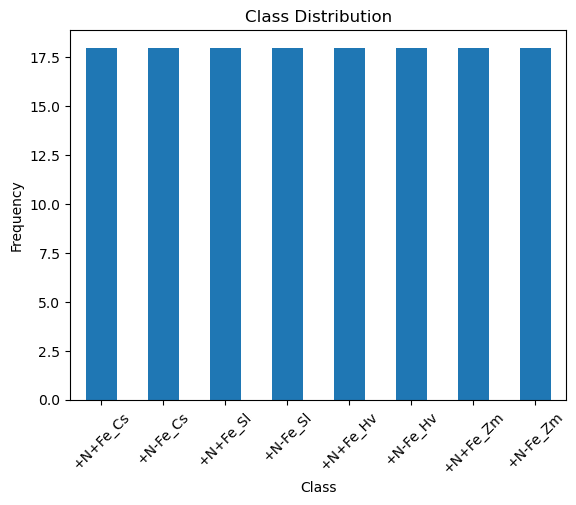

Columns with missing values: []

Outlier records/rows in the dataset:
Row numbers of outliers: [ 30  31  32  33  34  35  91  92  93  94  95  96  97  98  99 101 104 105
 106 107 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143]

Number of features with 0.0 importance: 97
Features with 0.0 importance: ['X400.20', 'X411.74', 'X417.52', 'X423.29', 'X426.19', 'X440.66', 'X481.32', 'X490.06', 'X504.64', 'X510.48', 'X513.40', 'X516.33', 'X528.03', 'X533.89', 'X539.75', 'X542.68', 'X548.55', 'X551.49', 'X557.36', 'X563.24', 'X566.18', 'X569.12', 'X589.75', 'X592.70', 'X604.51', 'X607.46', 'X616.34', 'X619.30', 'X637.08', 'X643.01', 'X675.73', 'X681.69', 'X687.65', 'X690.64', 'X705.57', 'X720.54', 'X729.53', 'X732.53', 'X735.53', 'X741.53', 'X747.54', 'X750.54', 'X759.56', 'X762.57', 'X768.60', 'X771.61', 'X774.62', 'X777.64', 'X780.65', 'X783.67', 'X786.68', 'X792.72', 'X795.74', 'X801.79', 'X804.81', 'X810.86', 'X816.92', 'X826.01', 'X829.04', 'X832.07', 'X838.14', 'X8

In [6]:
# Load the dataset
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# Drop the 'Leaf' column
data = data.drop(columns=['Leaf'])
# Separate features
X = data.iloc[:, 3:]
feature_names = X.columns.tolist()
# Combine 'Thesis' (iron deficiency) and 'Species' (plant type) into a single target column
data['Combined_Target'] = data['Thesis'].astype(str) + '_' + data['Species'].astype(str)
unique_elements = data['Combined_Target'].unique()
print("Unique elements in 'Combined_Target':")
print(unique_elements)
# Encode the combined target
le = LabelEncoder()
y = le.fit_transform(data['Combined_Target'])
# Check the distribution of the new target variable
class_distribution = data['Combined_Target'].value_counts()
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")
# IQR (identify rows where at least one feature (column) has an outlier)------------------>??
print("\nOutlier records/rows in the dataset:")
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
# Print row numbers of the outliers
outlier_rows = np.where(outliers)[0]
print("Row numbers of outliers:", outlier_rows)
# print(X[outliers])

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced .columns.tolist()
# print("\nX_reduced.shape is ", X_reduced.shape)
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
#Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)

#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> <font color=red> Multi-Class </font>  Standard Logistic Regression </font>

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)
Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression - Test Set Accuracy: 0.9166666666666666
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.67      1.00      0.80         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         5
           5       0.75      0.60      0.67         5
           6       1.00      1.00      1.00         5
           7       1.00      0.80      0.89         5

    accuracy                           0.92        36
   macro avg       0.93      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



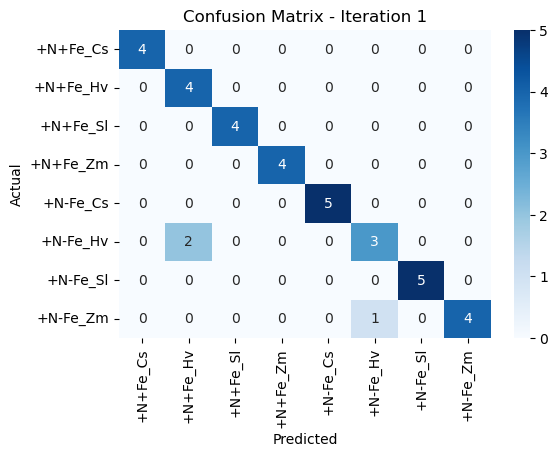

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression - Test Set Accuracy: 0.9444444444444444
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      1.00      1.00         6
           2       1.00      0.83      0.91         6
           3       1.00      0.83      0.91         6
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3

    accuracy                           0.94        36
   macro avg       0.97      0.96      0.96        36
weighted avg       0.96      0.94      0.95        36



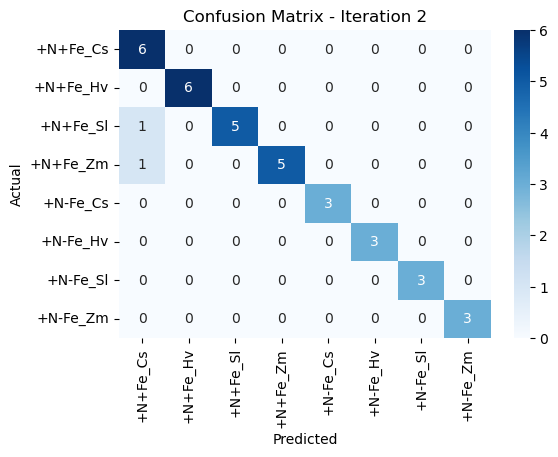

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)
Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression - Test Set Accuracy: 1.0
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         5

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



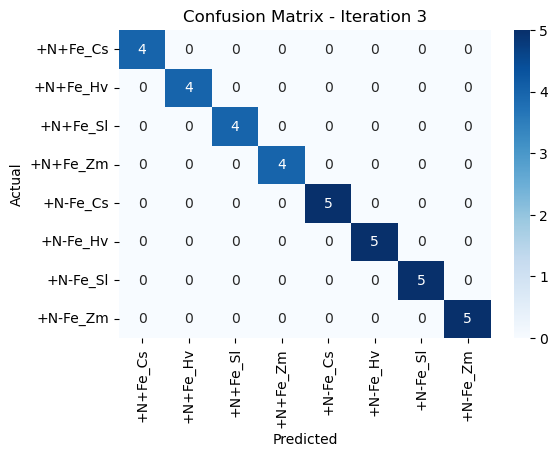

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)
Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression - Test Set Accuracy: 0.9444444444444444
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         4
           4       0.80      0.80      0.80         5
           5       1.00      0.80      0.89         5
           6       0.83      1.00      0.91         5
           7       1.00      1.00      1.00         5

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



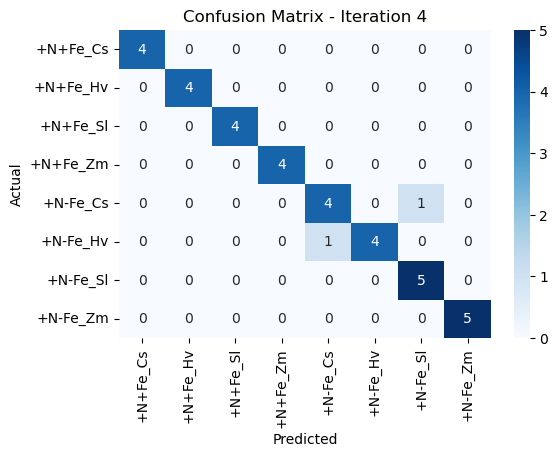


Average Accuracy Across 4 Iterations: 0.9513888888888888


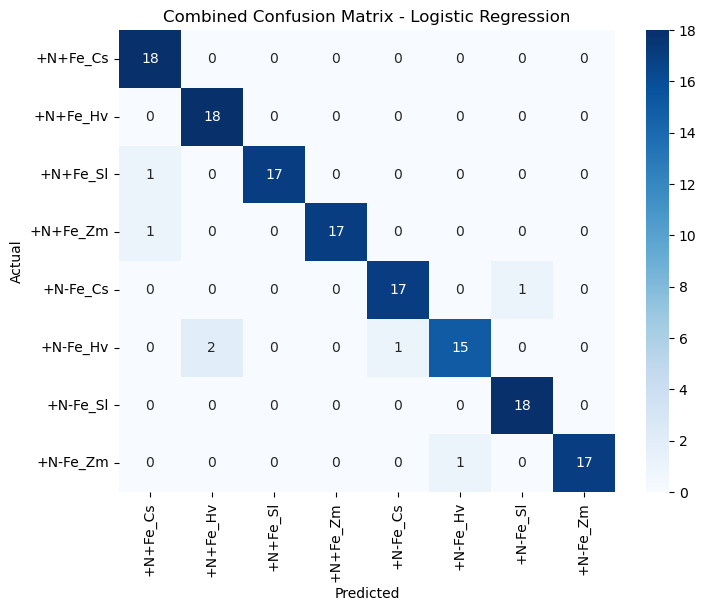


Overall Precision: 0.9513888888888888
Overall Recall: 0.9513888888888888
Overall F1-score: 0.9513888888888888
Length of feature names in combined_explanation: 204
Generating SHAP plots for Class: +N+Fe_Cs


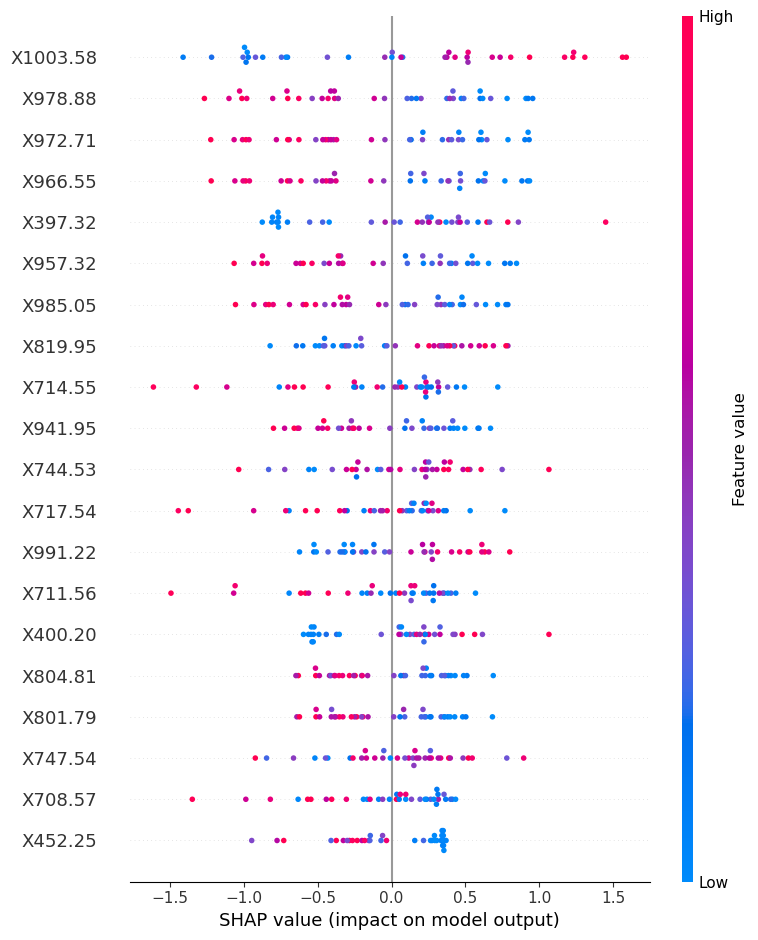

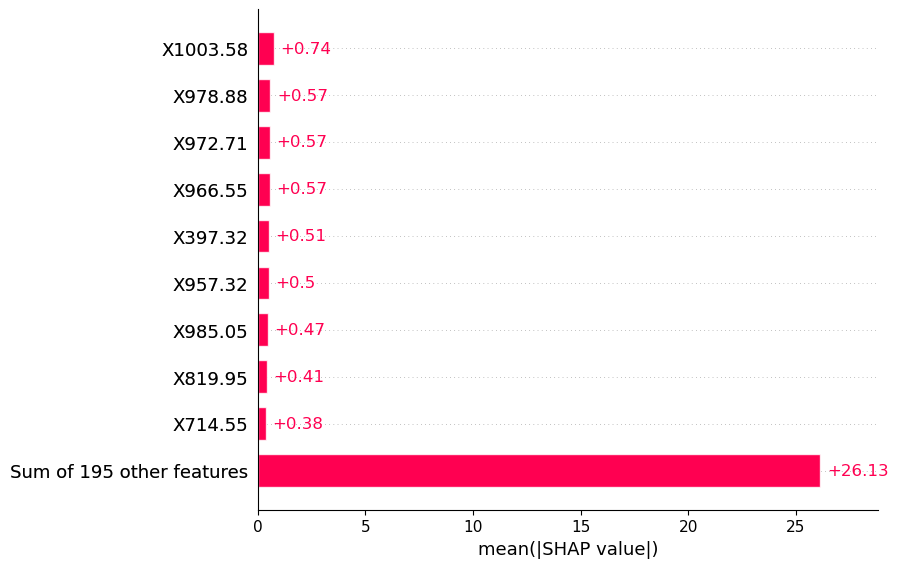

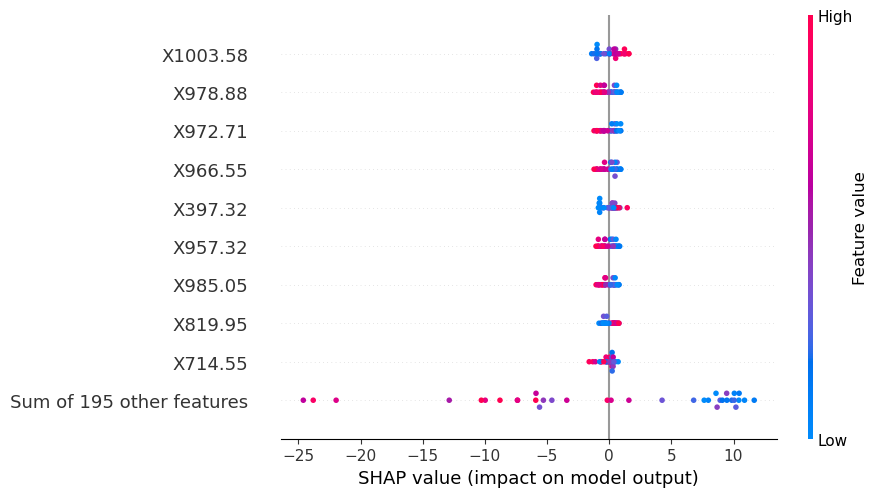

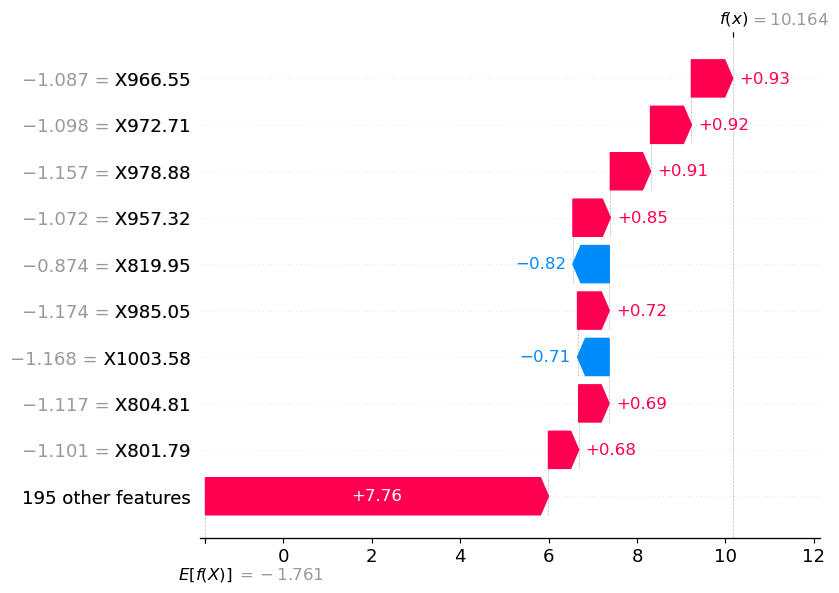

Generating SHAP plots for Class: +N+Fe_Hv


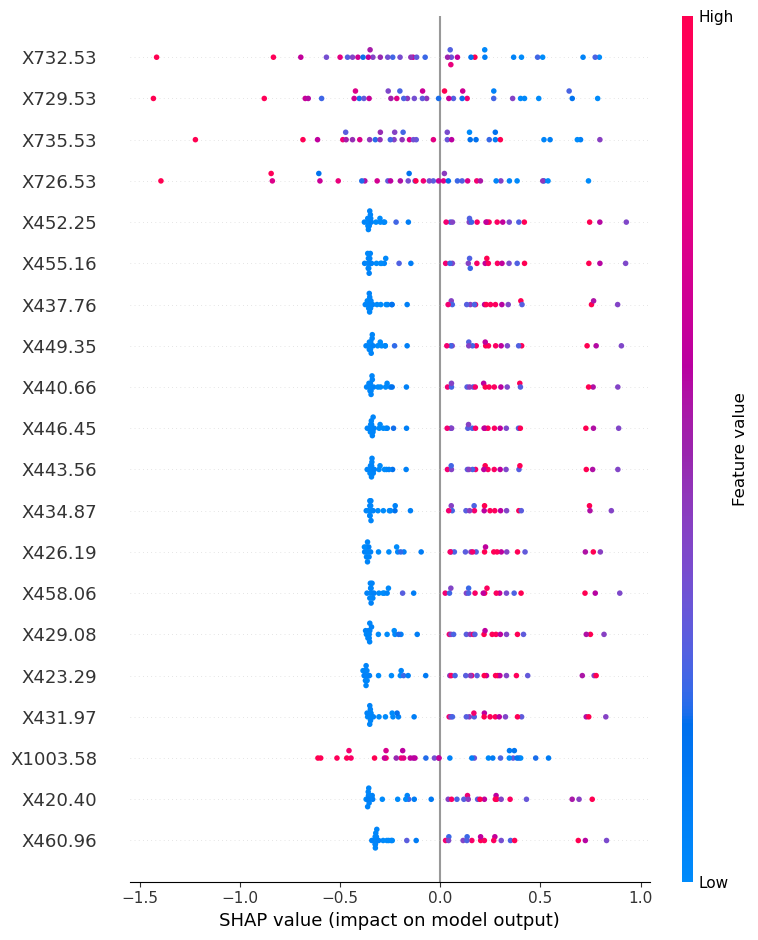

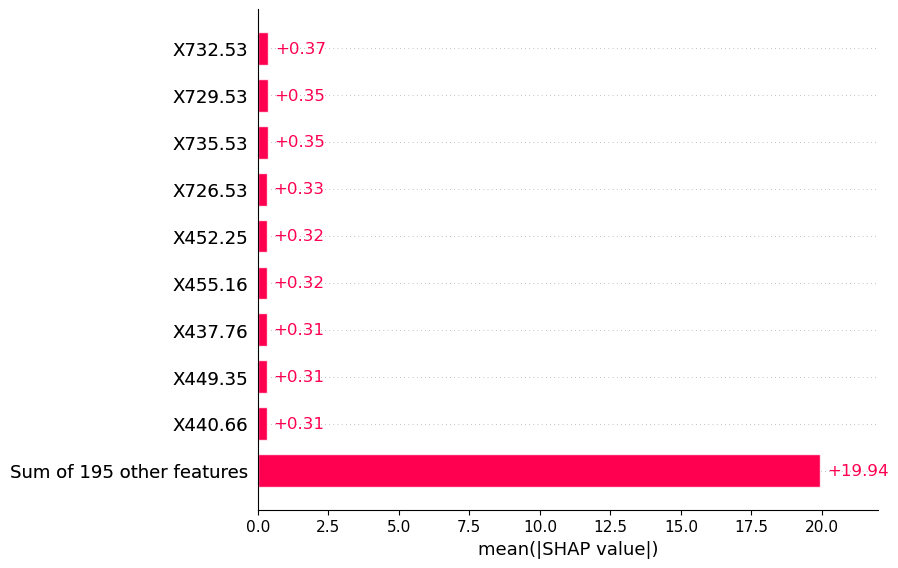

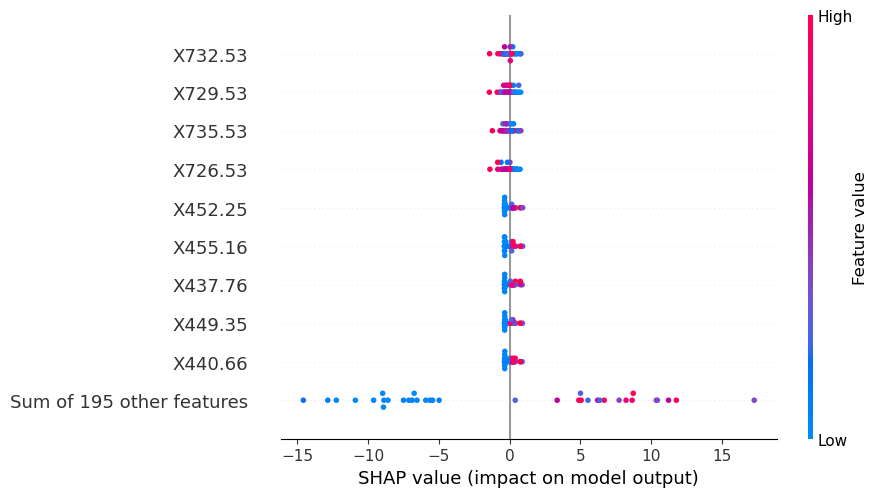

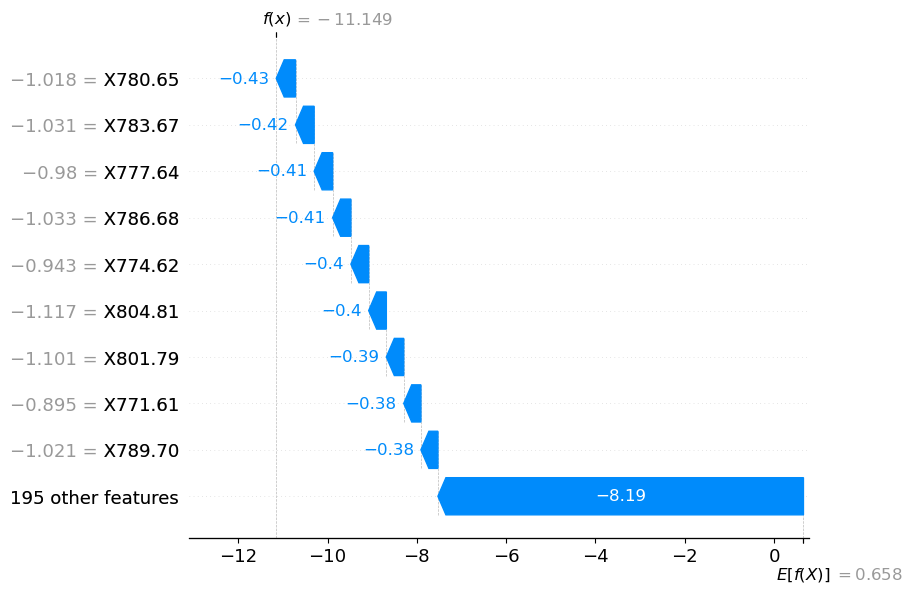

Generating SHAP plots for Class: +N+Fe_Sl


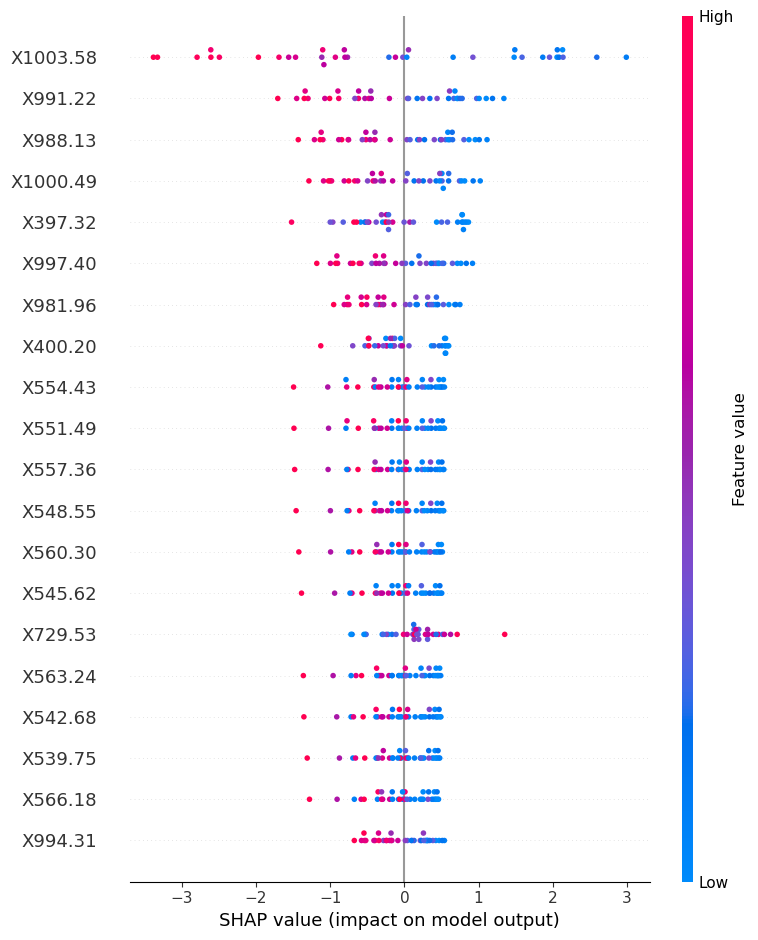

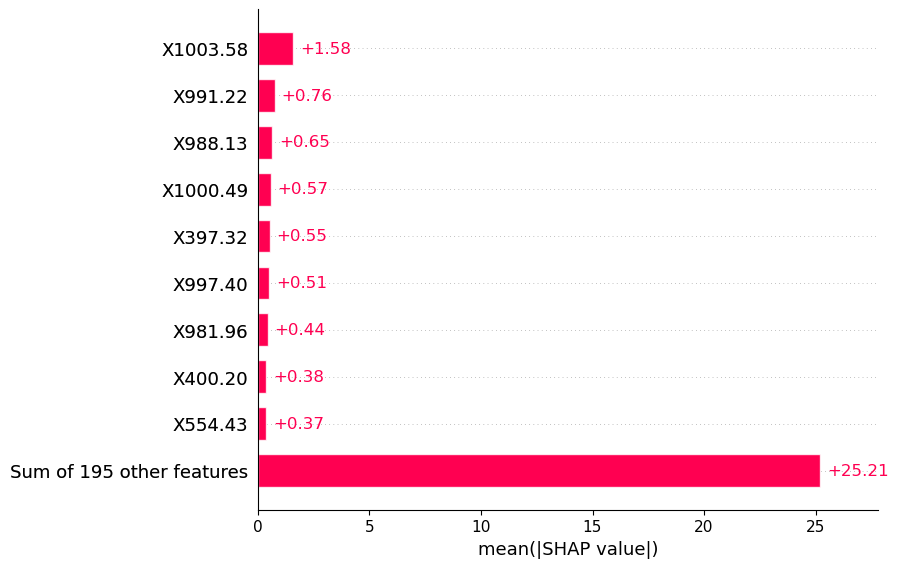

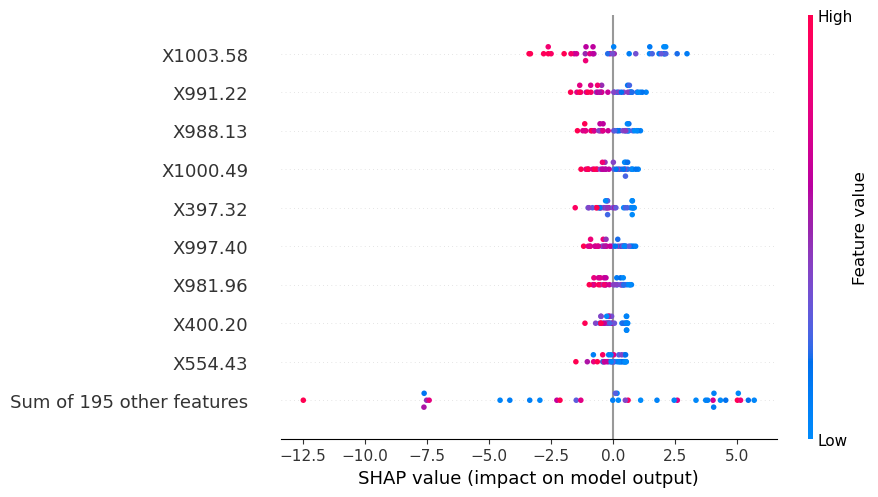

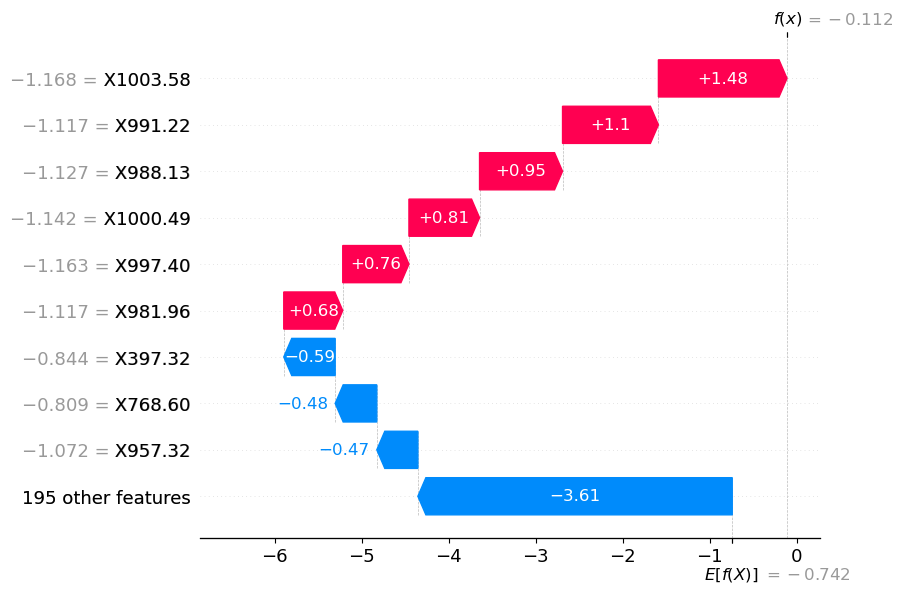

Generating SHAP plots for Class: +N+Fe_Zm


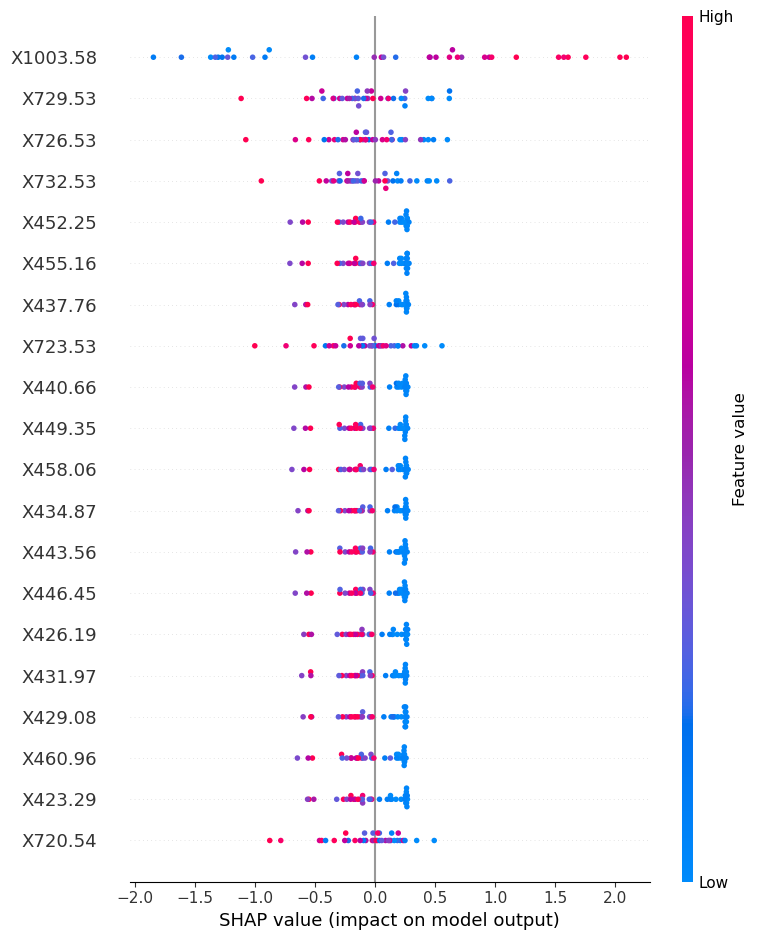

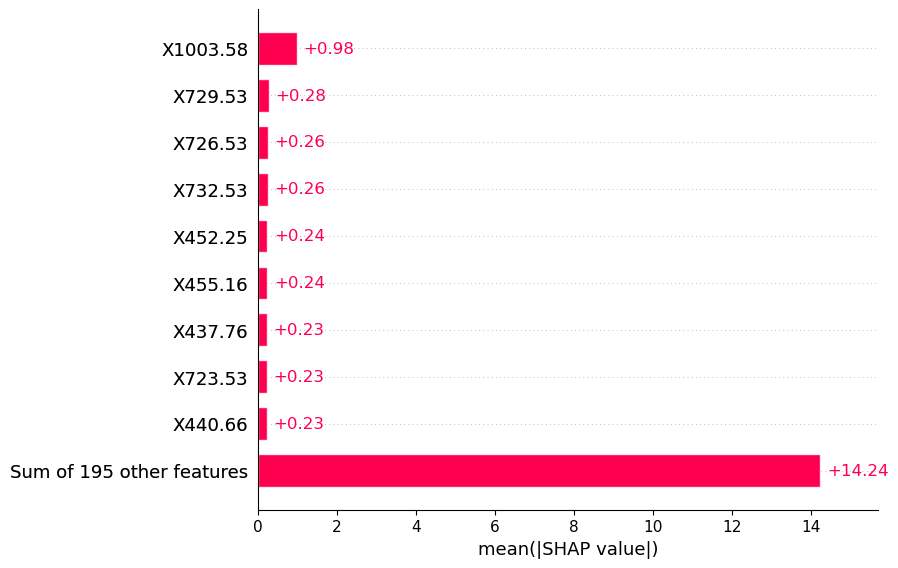

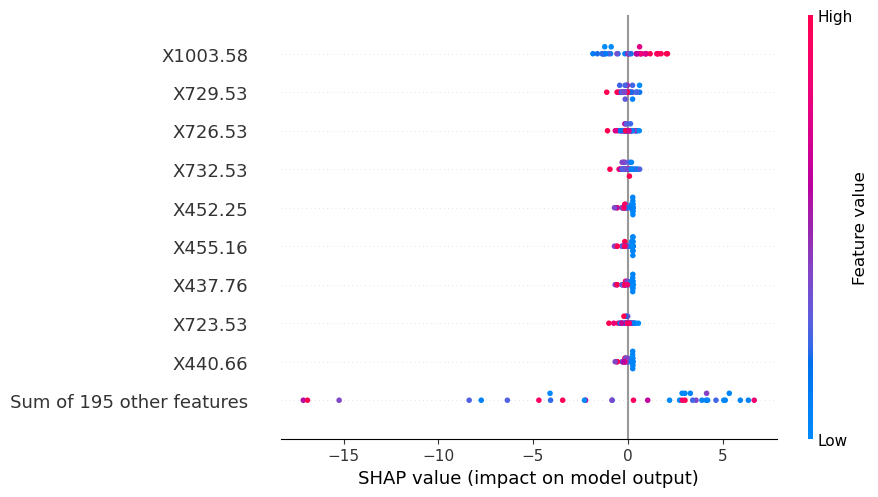

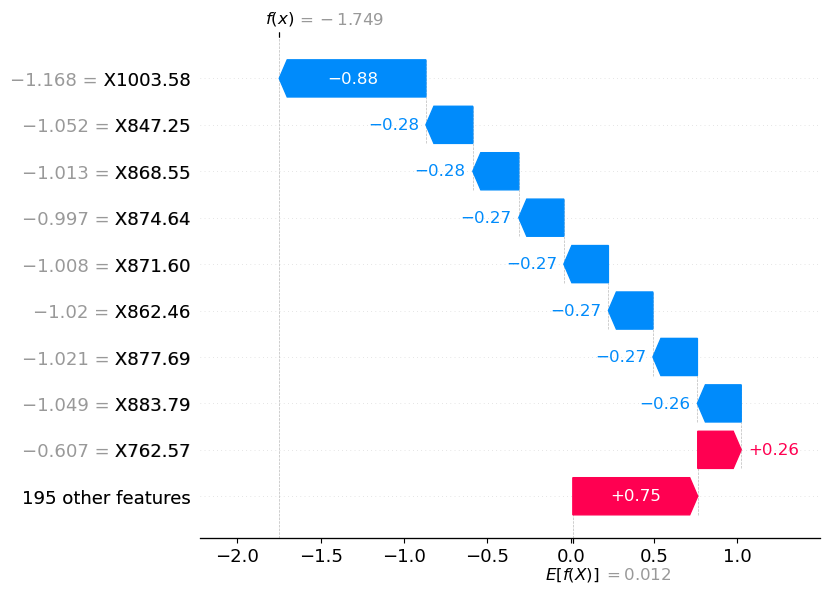

Generating SHAP plots for Class: +N-Fe_Cs


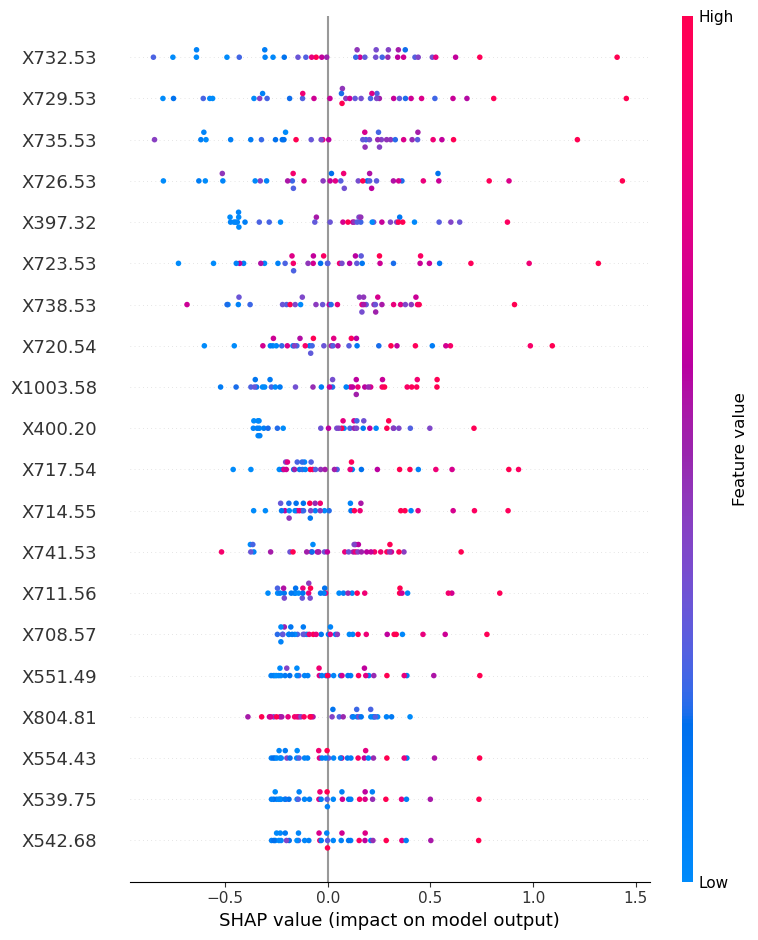

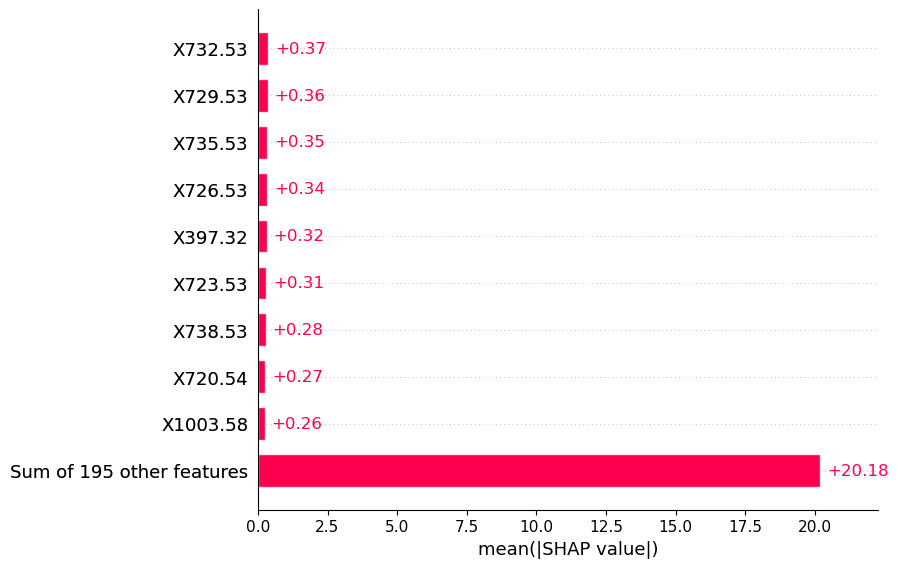

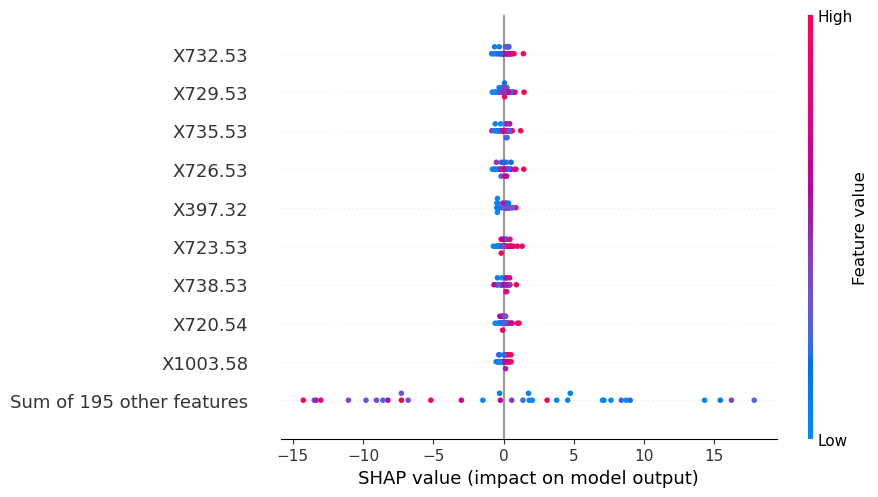

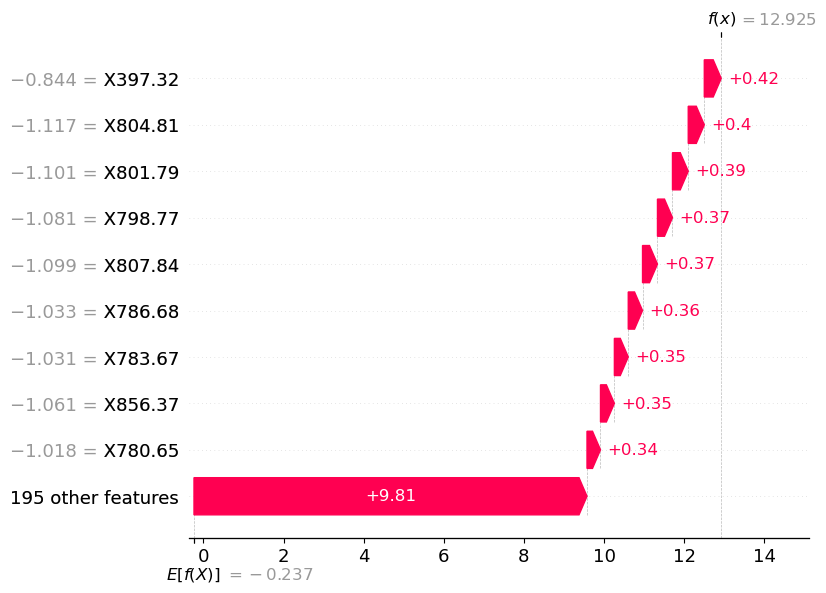

Generating SHAP plots for Class: +N-Fe_Hv


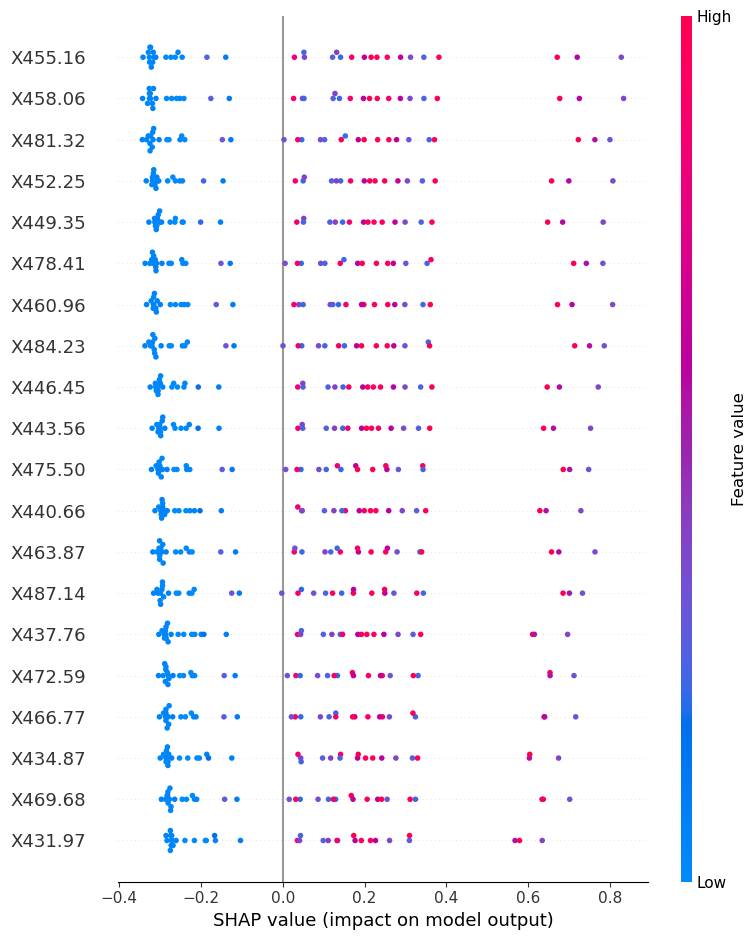

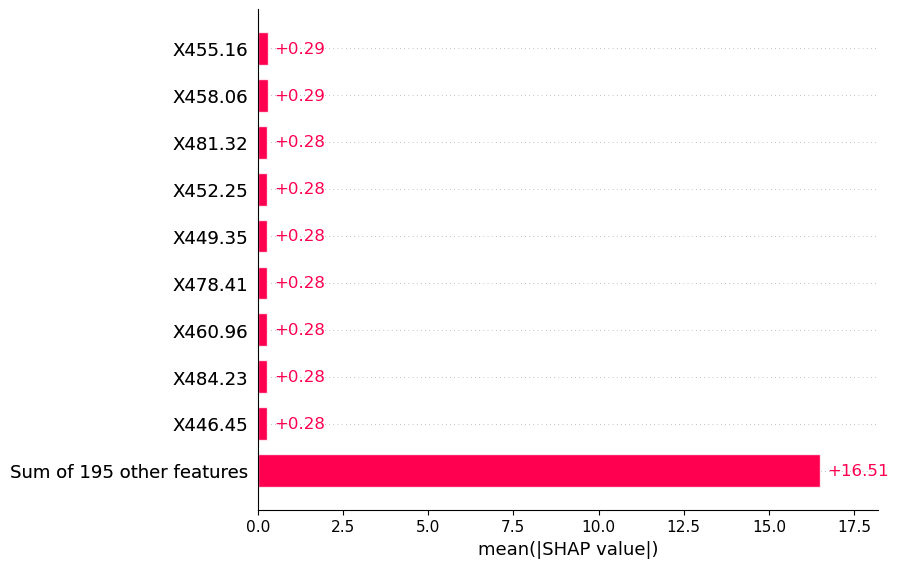

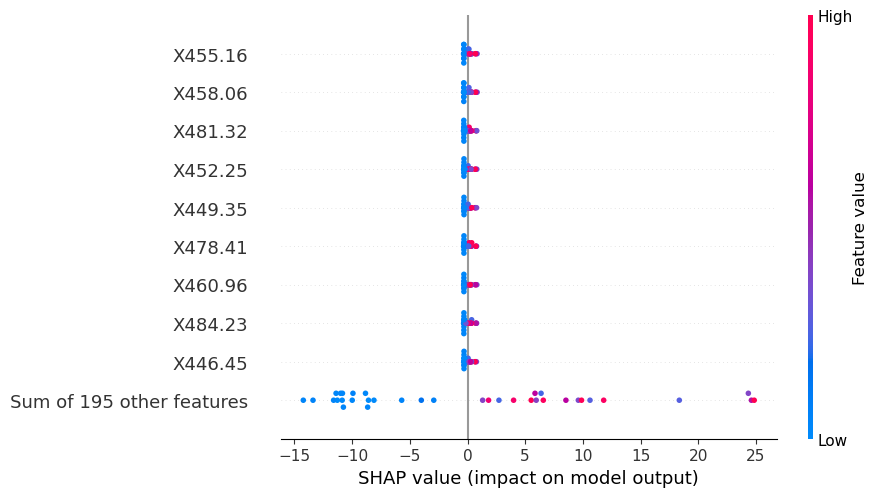

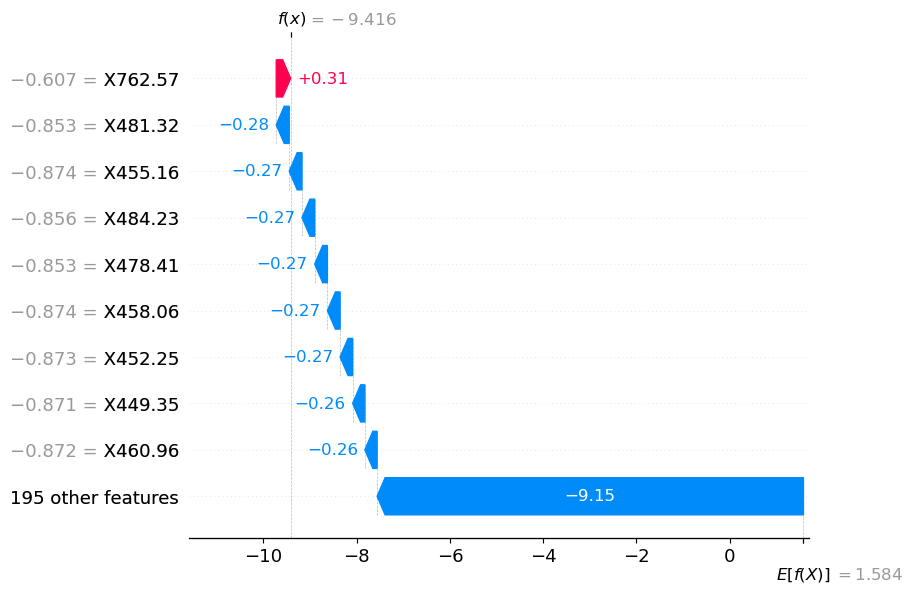

Generating SHAP plots for Class: +N-Fe_Sl


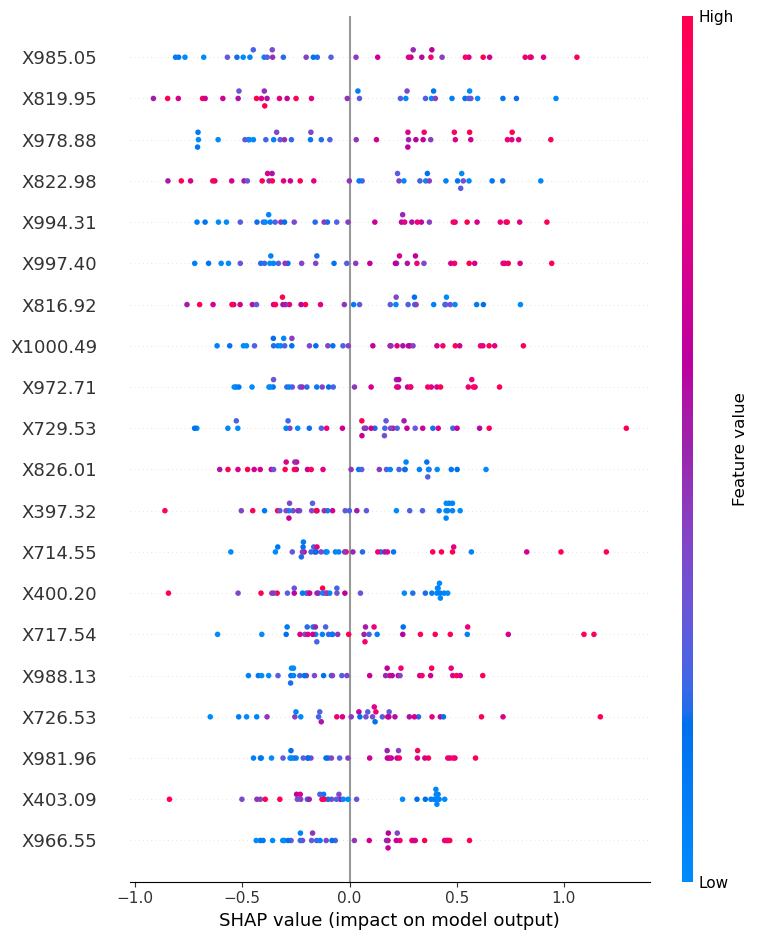

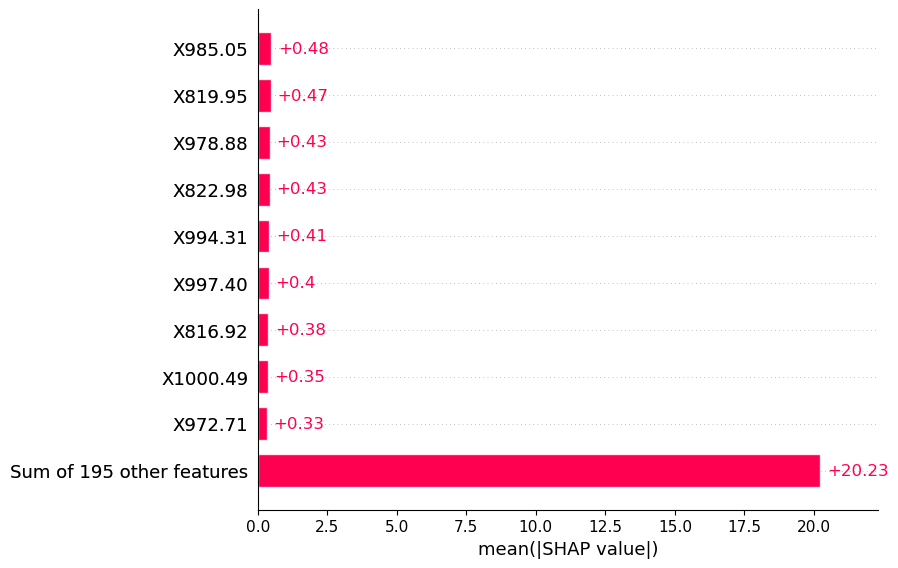

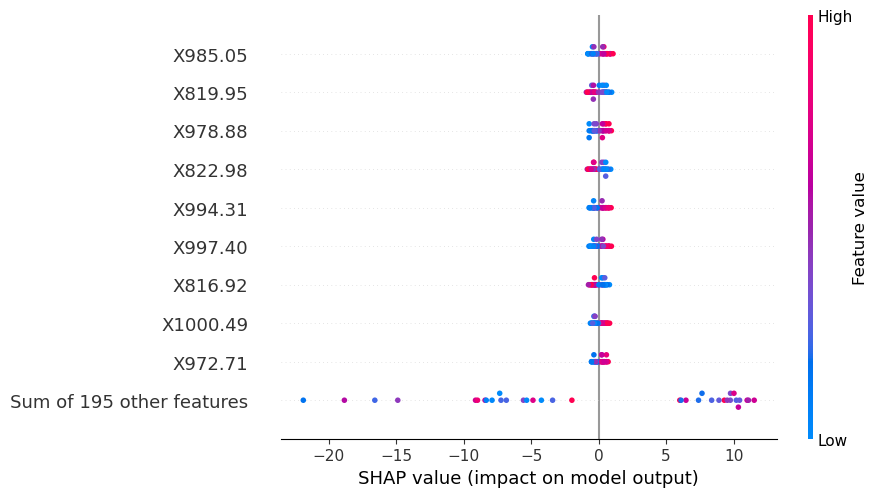

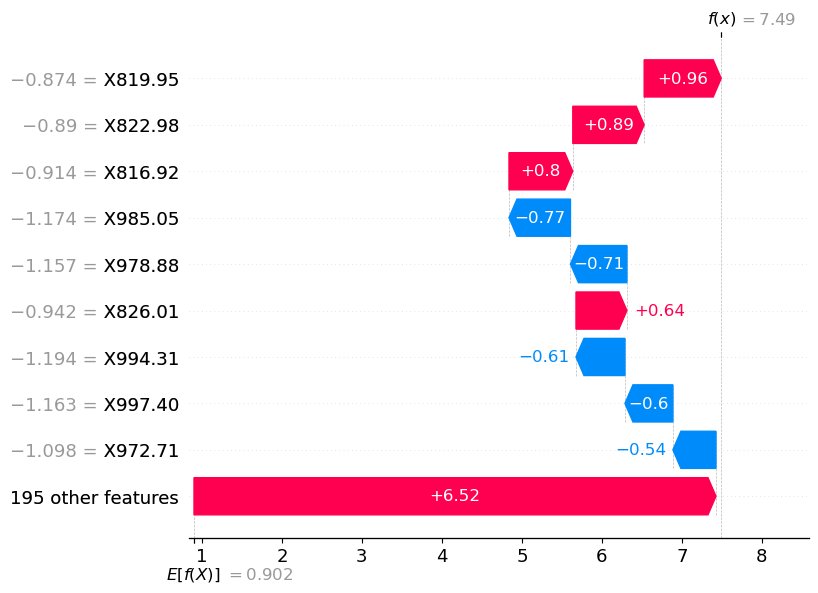

Generating SHAP plots for Class: +N-Fe_Zm


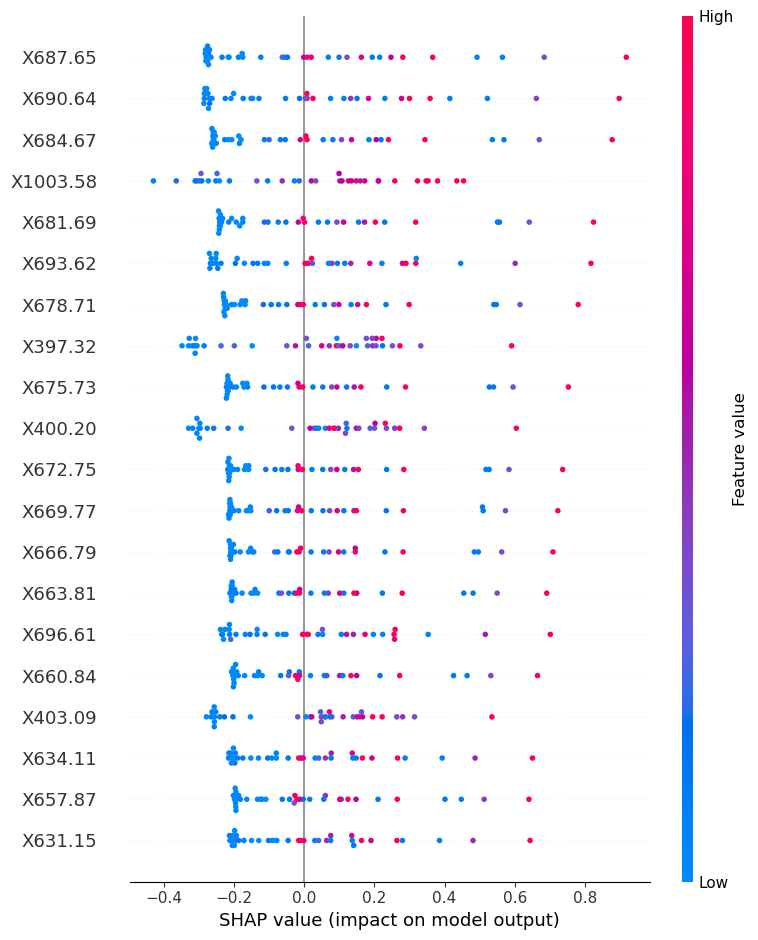

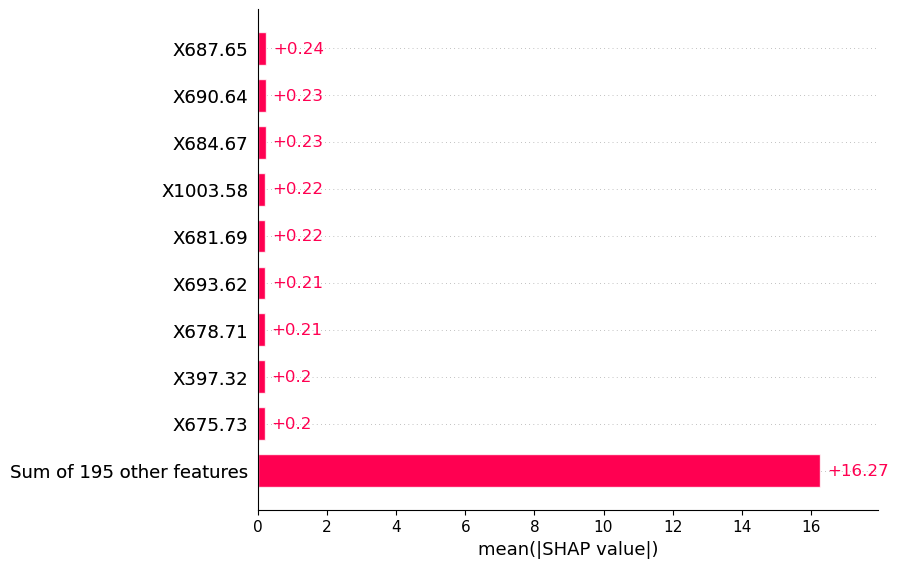

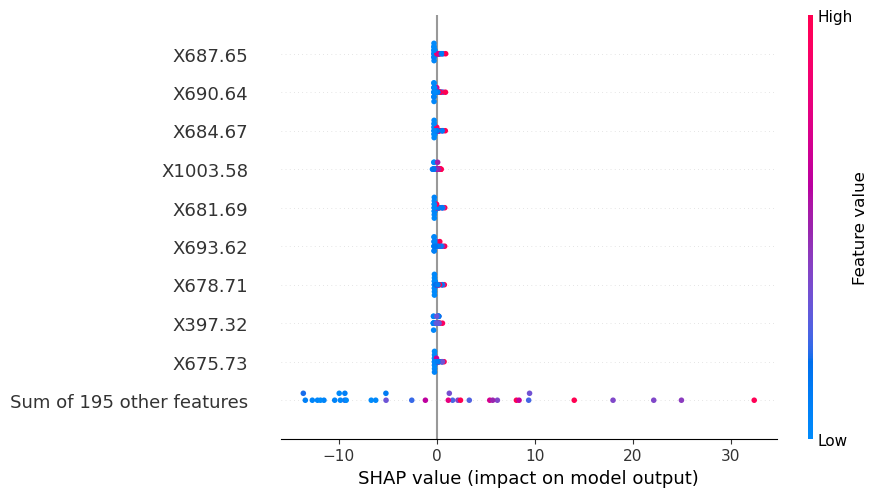

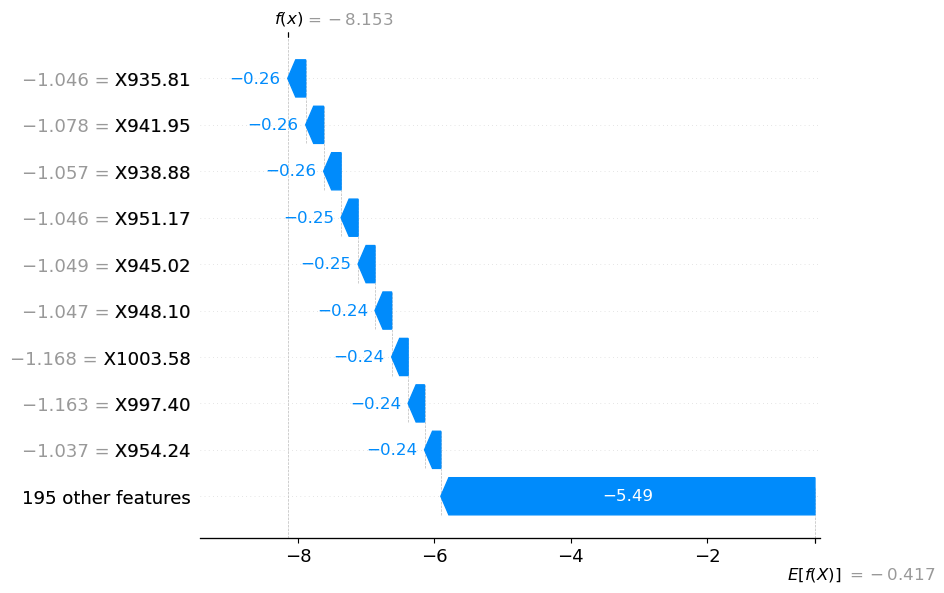

In [4]:
# Function to train and evaluate a model, and compute SHAP values
def train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names):
    # Define the parameter grid for Logistic Regression
    param_grid_lr = {
        'C': [0.01, 0.1, 1, 10, 30],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
    }

    # Initialize the Logistic Regression model
    lr_model = LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state)

    # Perform GridSearchCV with cross-validation
    grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=5, scoring='accuracy')
    grid_search_lr.fit(X_train, y_train)
    best_params_lr = grid_search_lr.best_params_
    print("Best parameters for Logistic Regression:", best_params_lr)

    # Train the best model on the entire training set
    best_lr_model = LogisticRegression(**best_params_lr, max_iter=1000, tol=1e-3, random_state=random_state)
    best_lr_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = best_lr_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print("\nLogistic Regression - Test Set Accuracy:", accuracy)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Calculate SHAP values
    explainer = shap.Explainer(best_lr_model, X_train)
    shap_values = explainer(X_test)
    return accuracy, conf_matrix, y_test, y_pred, shap_values, feature_names


# Initialize random state
random_state = 42

# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}

# 😶😶😶😶😶😶😶😶😶😶😶😶
# Shuffle the data for each plant once before starting the for loops
for plant in plant_groups_scaled.keys():
    X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
    plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
accuracies = []
conf_matrices = []
all_y_true = []
all_y_pred = []
shap_values_list = []

# Number of splits
n_splits = 4

# Iterate to split the dataset
for i in range(n_splits):
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Iterate over each plant species
    for plant in plant_groups_scaled.keys():
        X = plant_groups_scaled[plant][0]
        y = plant_groups_scaled[plant][1]
        
        # Define the indices for the current split
        test_size = len(X) // n_splits
        test_indices = range(i * test_size, (i + 1) * test_size)
        train_indices = list(set(range(len(X))) - set(test_indices))
        
        # Split the data for the current iteration
        X_train_plant = X[train_indices]
        y_train_plant = y[train_indices]
        X_test_plant = X[test_indices]
        y_test_plant = y[test_indices]
        
        # Append to the respective lists
        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

    # Concatenate the lists to form the final train and test sets
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    # 😶😶😶😶😶😶😶😶😶😶😶😶
    # Shuffle the concatenated train and test sets to remove any order-based bias
    X_train, y_train = shuffle(X_train, y_train, random_state=random_state)
    # X_test, y_test = shuffle(X_test, y_test, random_state=random_state)
   
    # Confirm the shape of the train and test sets
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Train and evaluate the model, and get SHAP values
    accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names = train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names)
    # accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names = train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names_reduced)
    accuracies.append(accuracy)
    conf_matrices.append(conf_matrix)
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    shap_values_list.append(shap_values)

    # Plot the confusion matrix for each iteration
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - Iteration {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)
print("\nAverage Accuracy Across 4 Iterations:", average_accuracy)

# Combine confusion matrices by summing them up
combined_conf_matrix = np.sum(conf_matrices, axis=0)

# Plot the combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Combined Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate precision, recall, and F1-score using the aggregated results
precision = precision_score(all_y_true, all_y_pred, average='micro')
recall = recall_score(all_y_true, all_y_pred, average='micro')
f1 = f1_score(all_y_true, all_y_pred, average='micro')

print(f"\nOverall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall F1-score: {f1}")

# Aggregate SHAP values
mean_shap_values = np.mean([sv.values for sv in shap_values_list], axis=0)
combined_base_values = np.mean([sv.base_values for sv in shap_values_list], axis=0)

# Assuming X_test from the last iteration, or a combined test set
# Create an Explanation object with combined SHAP values
combined_explanation = shap.Explanation(
    values=mean_shap_values,
    base_values=combined_base_values,
    data=X_test,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Print the length of feature names in combined_explanation
print("Length of feature names in combined_explanation:", len(combined_explanation.feature_names))

# Generate SHAP plots for each class
for i in range(combined_explanation.shape[2]):
    print(f"Generating SHAP plots for Class: {le.classes_[i]}")

    # Summary Plot
    shap.summary_plot(combined_explanation.values[:, :, i], X_test, feature_names=combined_explanation.feature_names)
    
    # Bar Plot
    shap.plots.bar(shap.Explanation(
        values=combined_explanation.values[:, :, i],
        base_values=combined_explanation.base_values[:, i],
        data=X_test,
        feature_names=combined_explanation.feature_names
    ), max_display=10)
    
    # Beeswarm Plot
    shap.plots.beeswarm(shap.Explanation(
        values=combined_explanation.values[:, :, i],
        base_values=combined_explanation.base_values[:, i],
        data=X_test,
        feature_names=combined_explanation.feature_names
    ))
    
    # Waterfall Plot for the first instance
    shap.plots.waterfall(shap.Explanation(
        values=combined_explanation.values[0, :, i],
        base_values=combined_explanation.base_values[0, i],
        data=X_test[0],
        feature_names=combined_explanation.feature_names
    ))

#### <font color=green> <font color=red> Multi-Class </font> Random Forest </font>

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}

Random Forest - Test Set Accuracy: 0.8055555555555556
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.80      1.00      0.89         4
           2       0.80      1.00      0.89         4
           3       1.00      1.00      1.00         4
           4       0.67      0.80      0.73         5
           5       0.33      0.20      0.25         5
           6       1.00      0.80      0.89         5
           7       0.80      0.80      0.80         5

    accuracy                           0.81        36
   macro avg       0.80      0.82      0.81        36
weighted avg       0.79      0.81      0.79        36

shap_values_rf's shape (36, 204, 8)


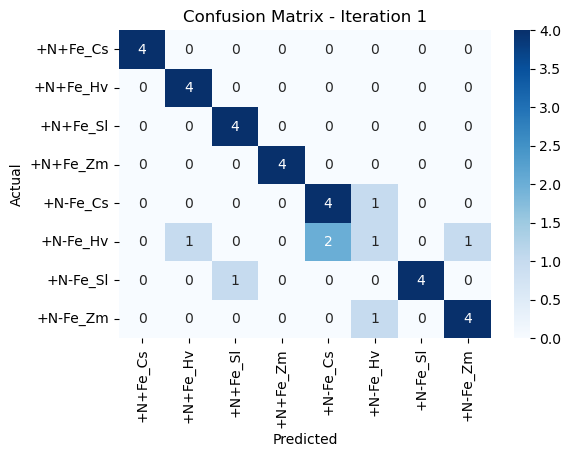

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 10}

Random Forest - Test Set Accuracy: 0.9166666666666666
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         6
           1       1.00      1.00      1.00         6
           2       1.00      0.50      0.67         6
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3

    accuracy                           0.92        36
   macro avg       0.96      0.94      0.93        36
weighted avg       0.94      0.92      0.91        36

shap_values_rf's shape (36, 204, 8)


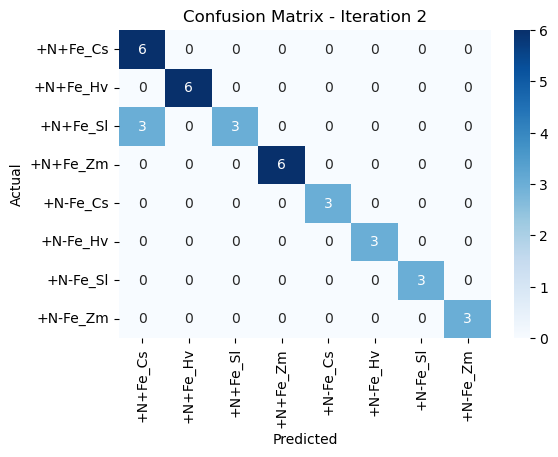

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}

Random Forest - Test Set Accuracy: 0.8611111111111112
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       1.00      1.00      1.00         4
           2       0.60      0.75      0.67         4
           3       1.00      1.00      1.00         4
           4       0.83      1.00      0.91         5
           5       0.83      1.00      0.91         5
           6       1.00      0.80      0.89         5
           7       1.00      0.80      0.89         5

    accuracy                           0.86        36
   macro avg       0.87      0.86      0.85        36
weighted avg       0.87      0.86      0.86        36

shap_values_rf's shape (36, 204, 8)


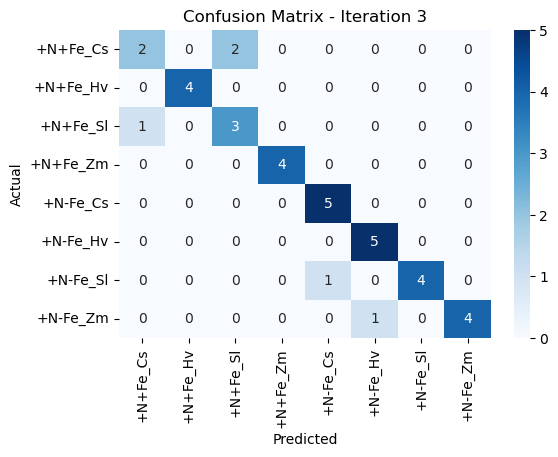

X_train shape: (108, 204), y_train shape: (108,)
X_test shape: (36, 204), y_test shape: (36,)


C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}

Random Forest - Test Set Accuracy: 0.8055555555555556
Test Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       0.80      1.00      0.89         4
           3       1.00      1.00      1.00         4
           4       1.00      0.60      0.75         5
           5       1.00      0.20      0.33         5
           6       0.67      0.80      0.73         5
           7       0.56      1.00      0.71         5

    accuracy                           0.81        36
   macro avg       0.88      0.82      0.80        36
weighted avg       0.87      0.81      0.78        36

shap_values_rf's shape (36, 204, 8)


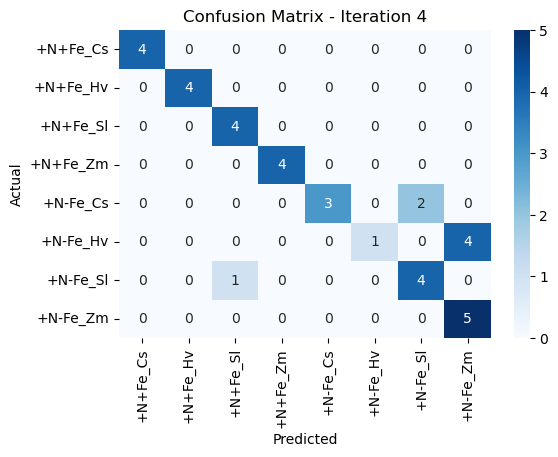


Average Accuracy Across 4 Iterations: 0.8472222222222223


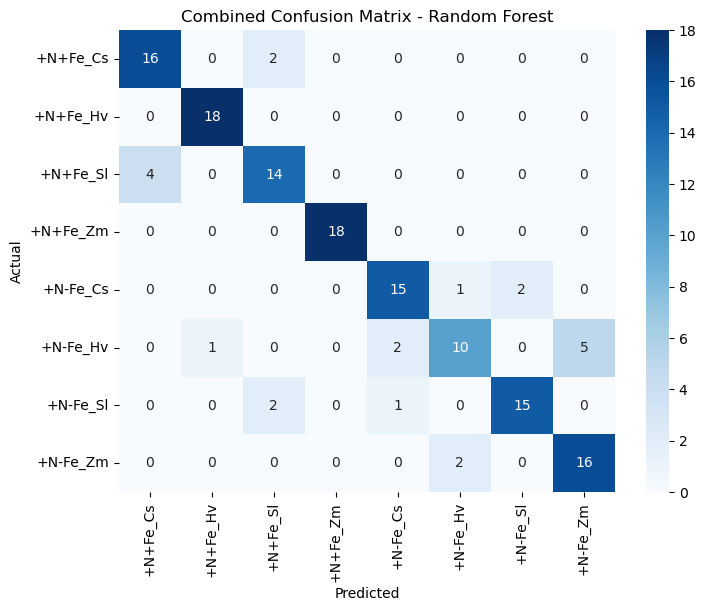


Overall Precision: 0.8472222222222222
Overall Recall: 0.8472222222222222
Overall F1-score: 0.8472222222222222
combined_base_values_rf's shape [0.12731481 0.11935185 0.10921296 0.12731481 0.13259259 0.12555556
 0.1249537  0.1337037 ]
Generating SHAP plots for Class: +N+Fe_Cs


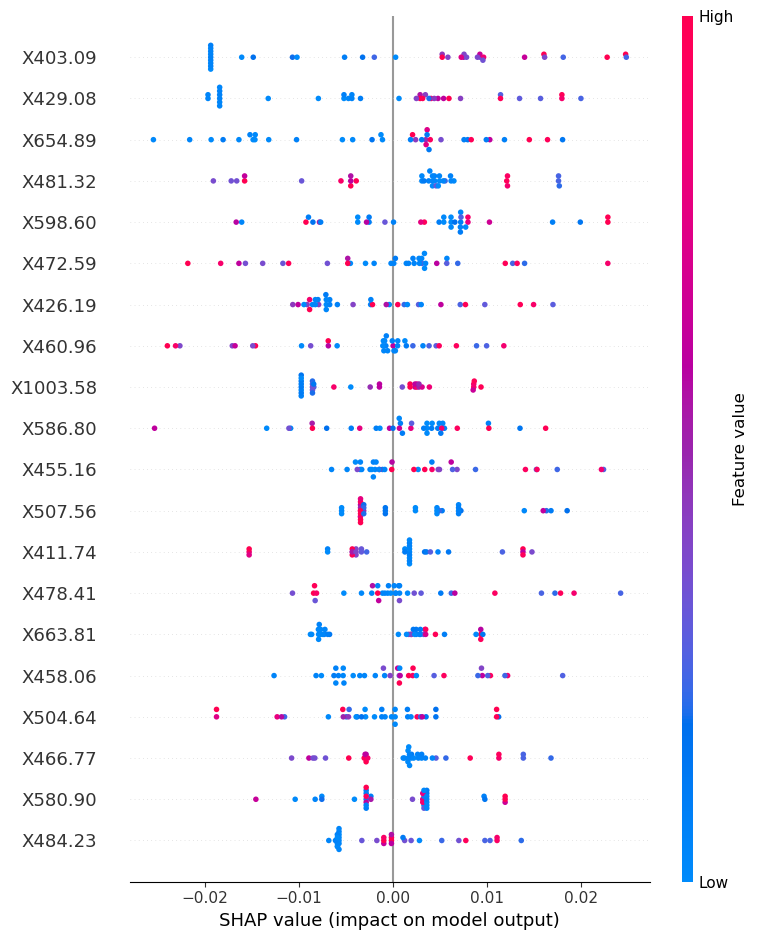

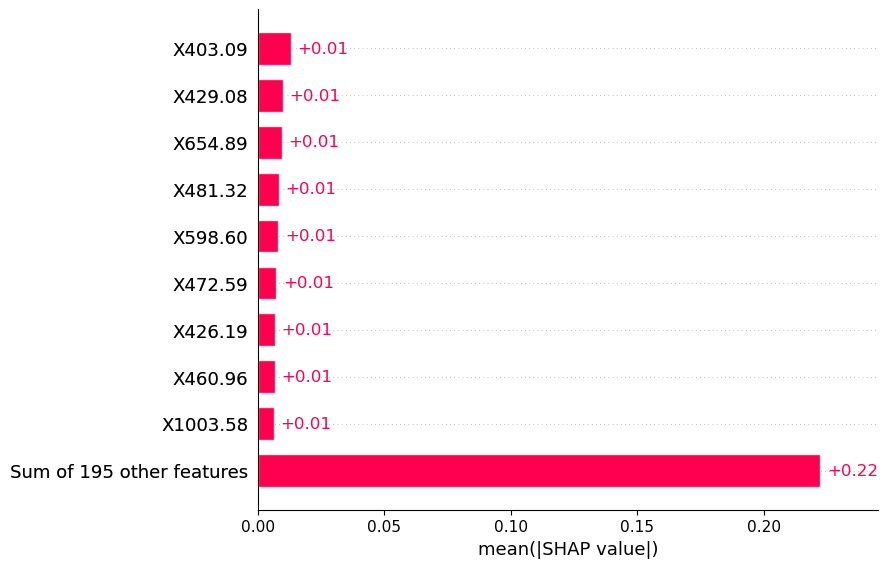

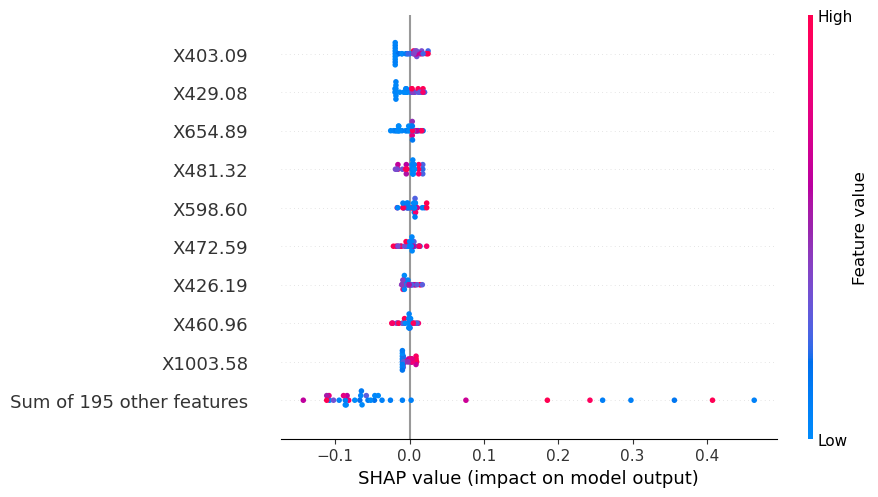

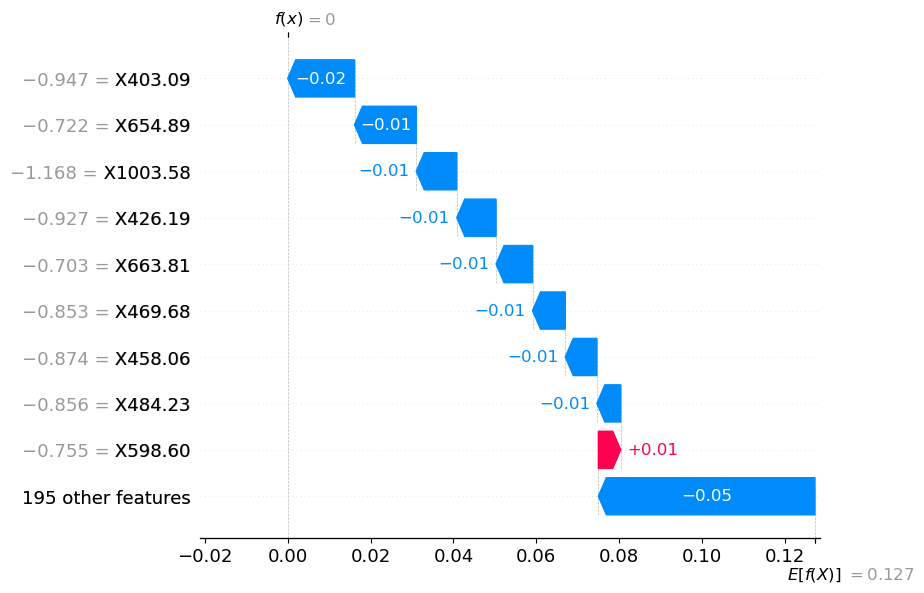

Generating SHAP plots for Class: +N+Fe_Hv


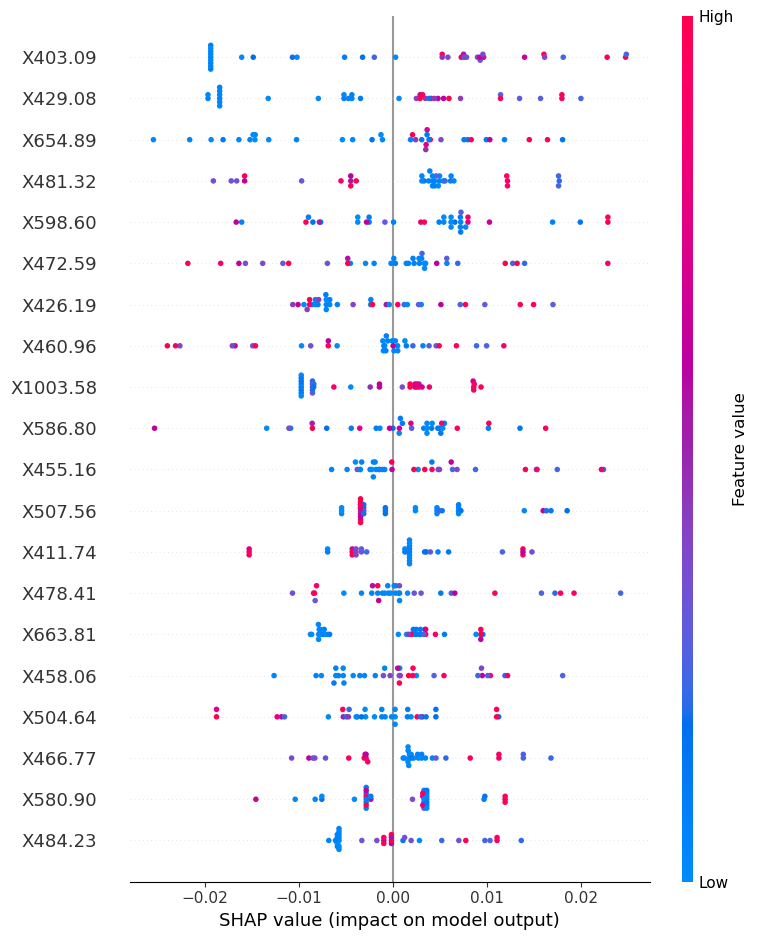

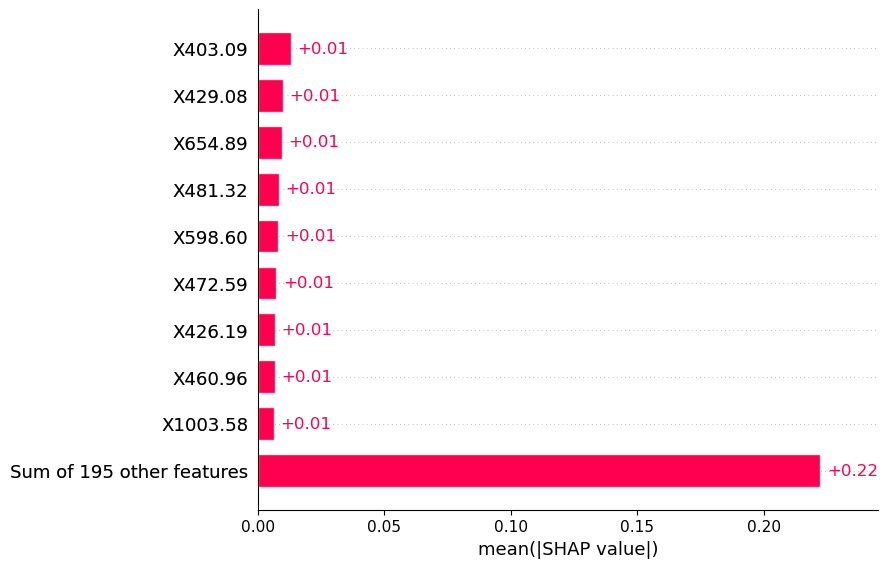

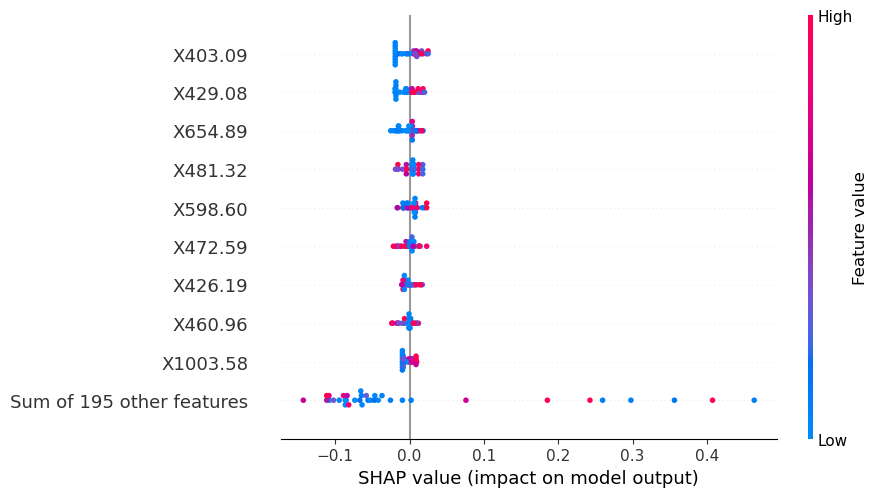

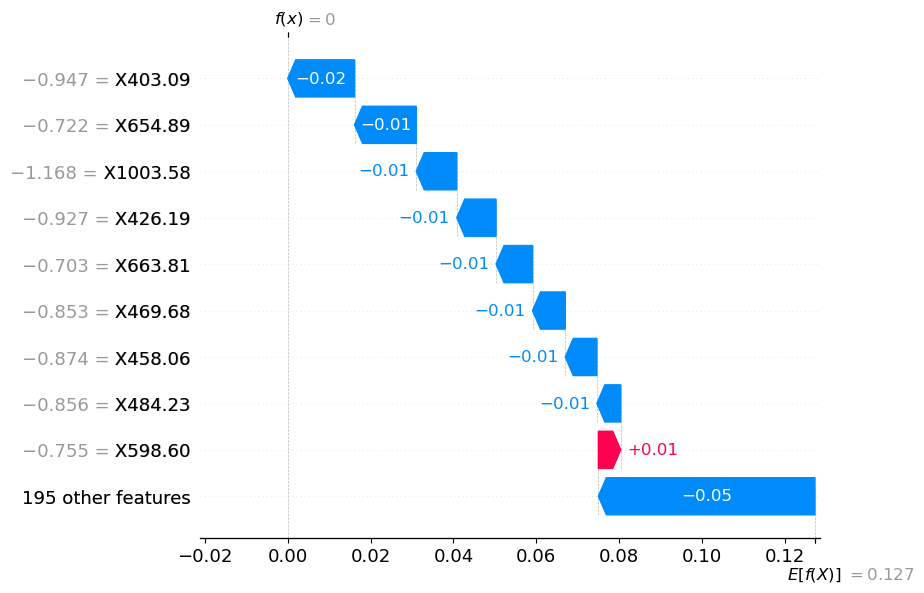

Generating SHAP plots for Class: +N+Fe_Sl


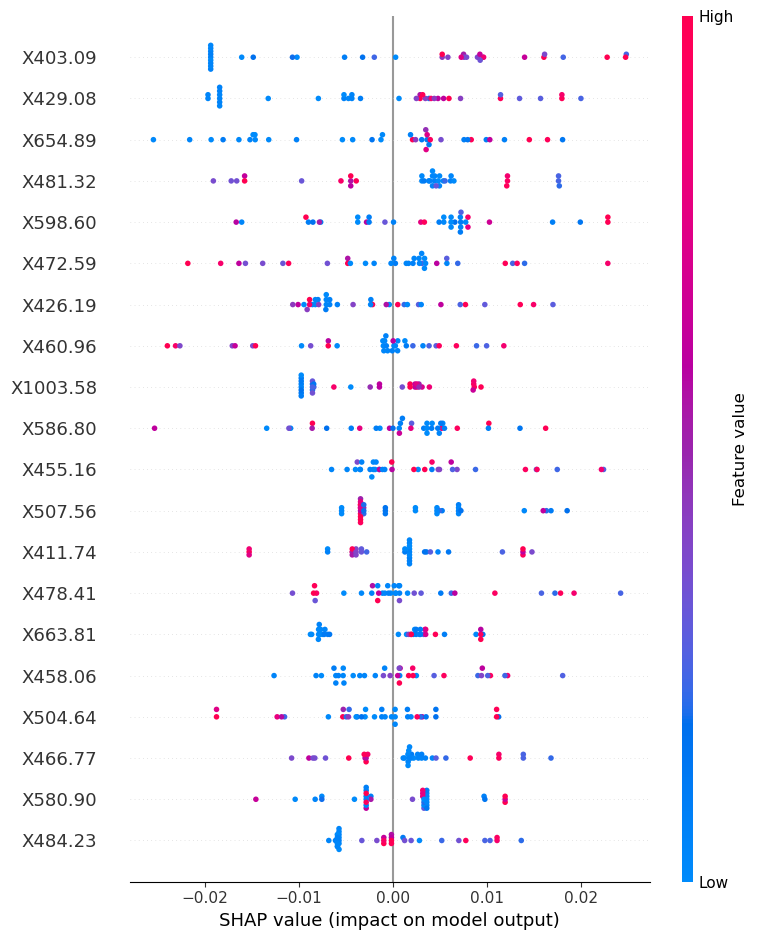

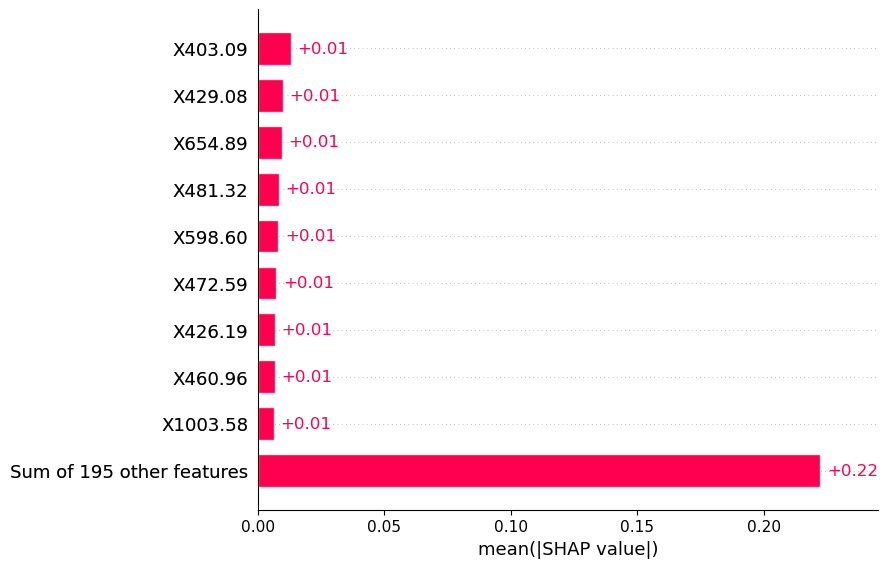

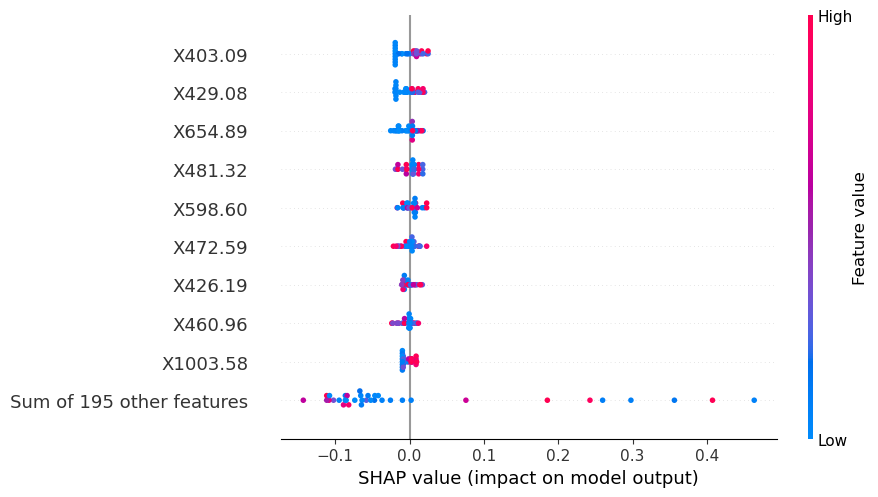

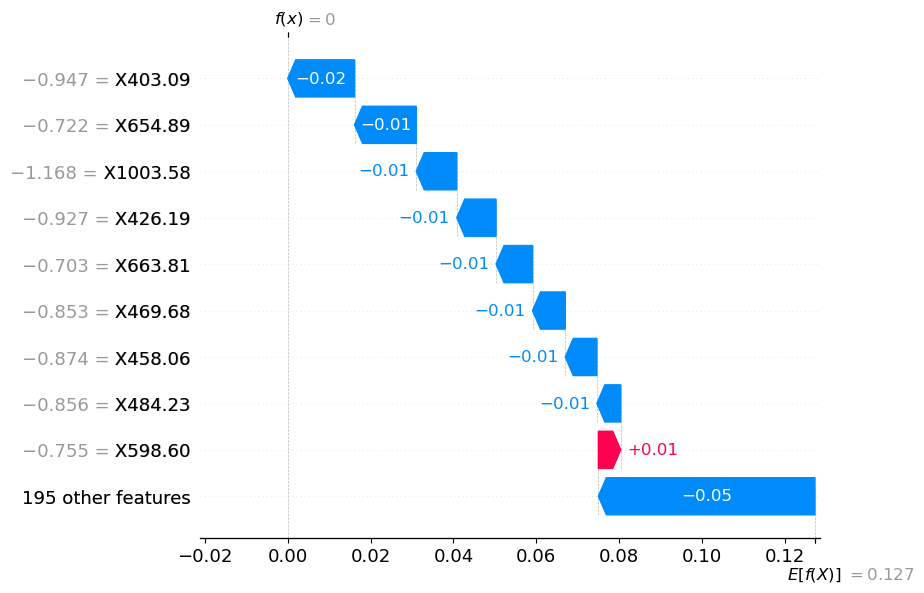

Generating SHAP plots for Class: +N+Fe_Zm


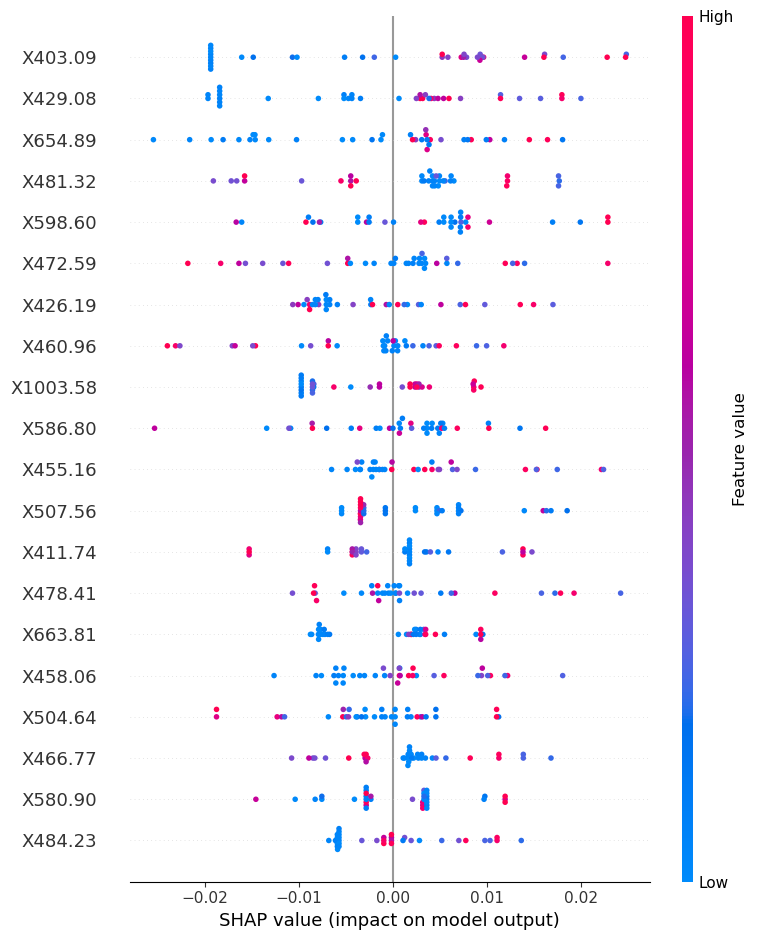

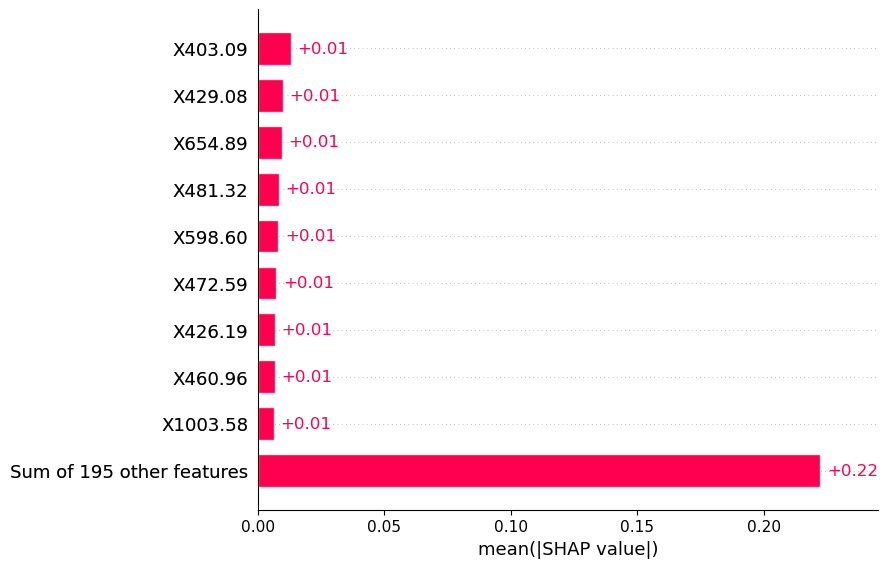

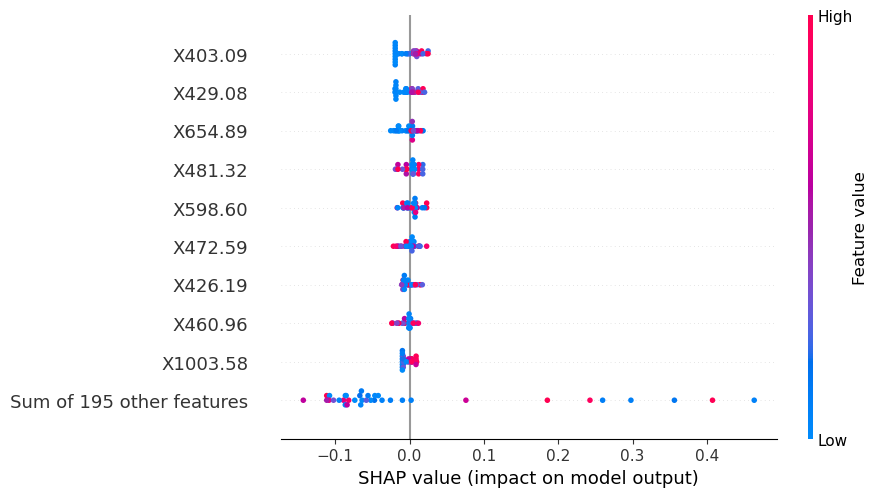

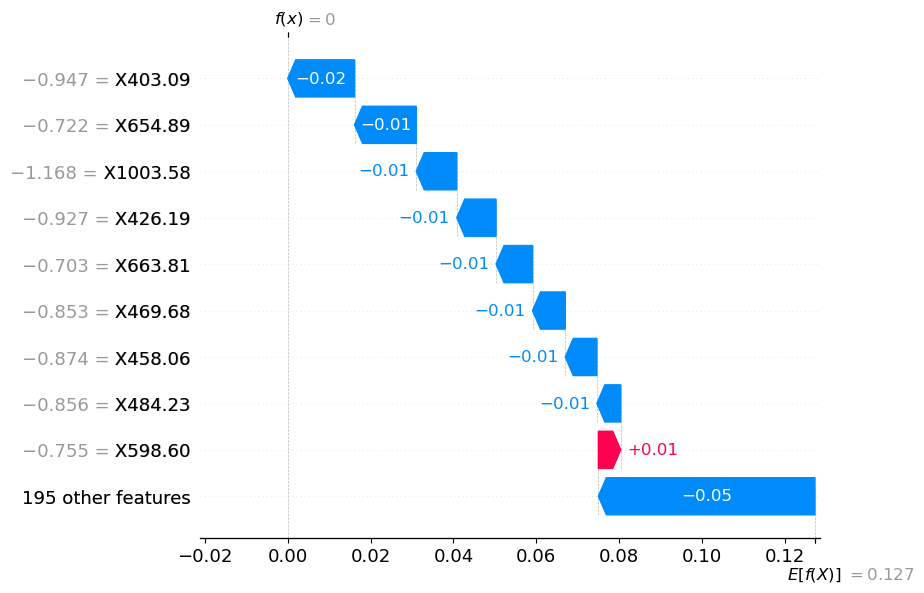

Generating SHAP plots for Class: +N-Fe_Cs


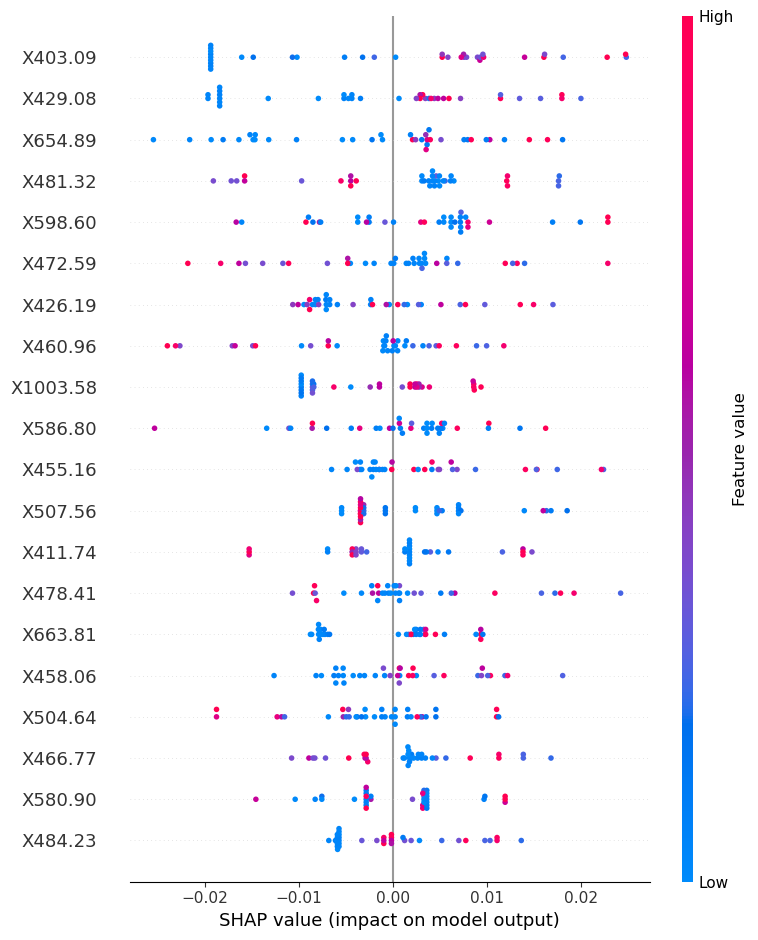

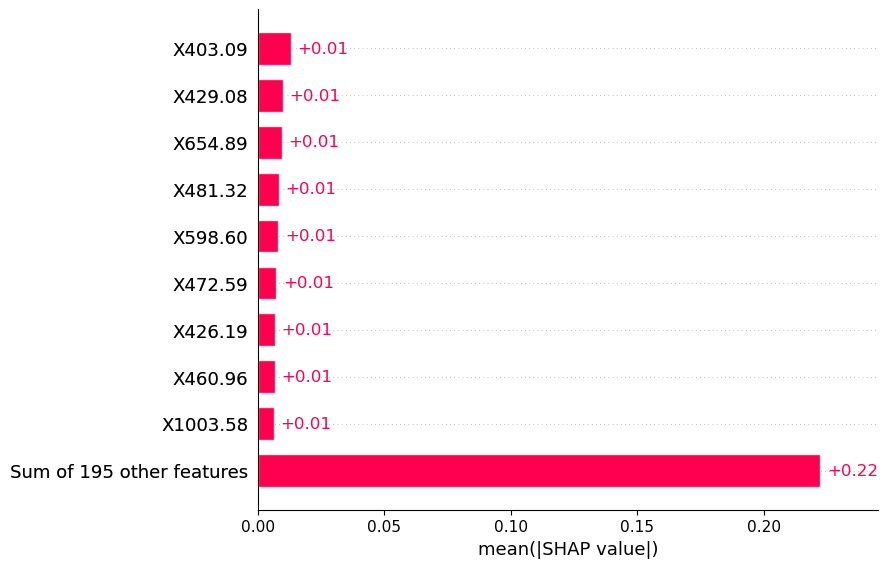

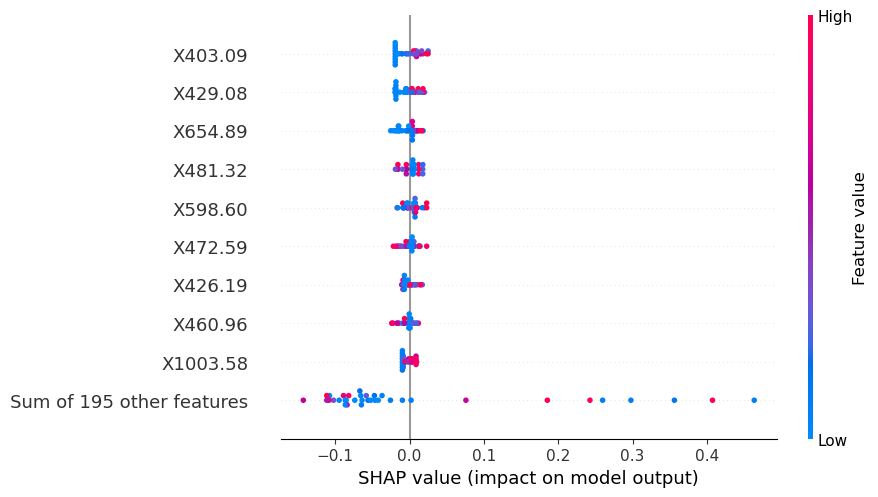

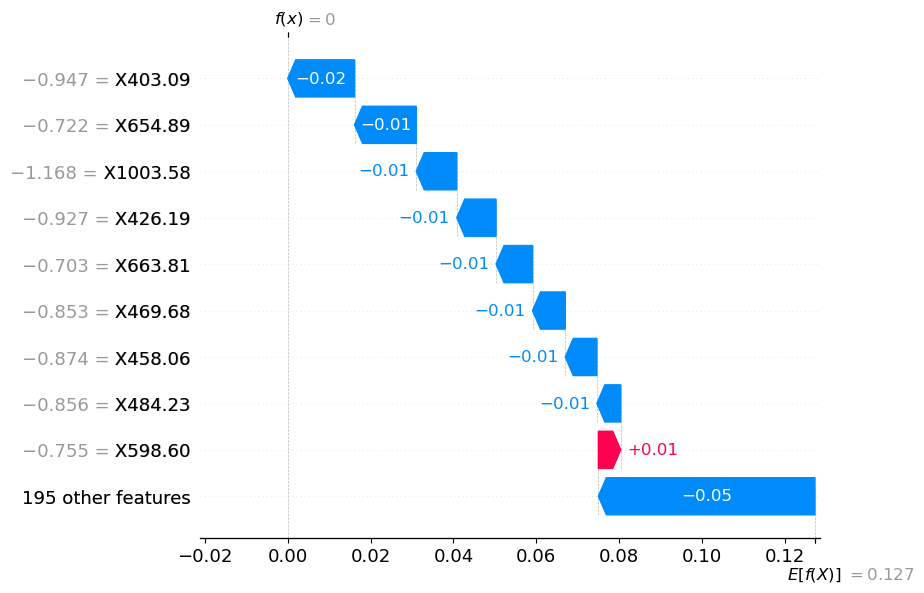

Generating SHAP plots for Class: +N-Fe_Hv


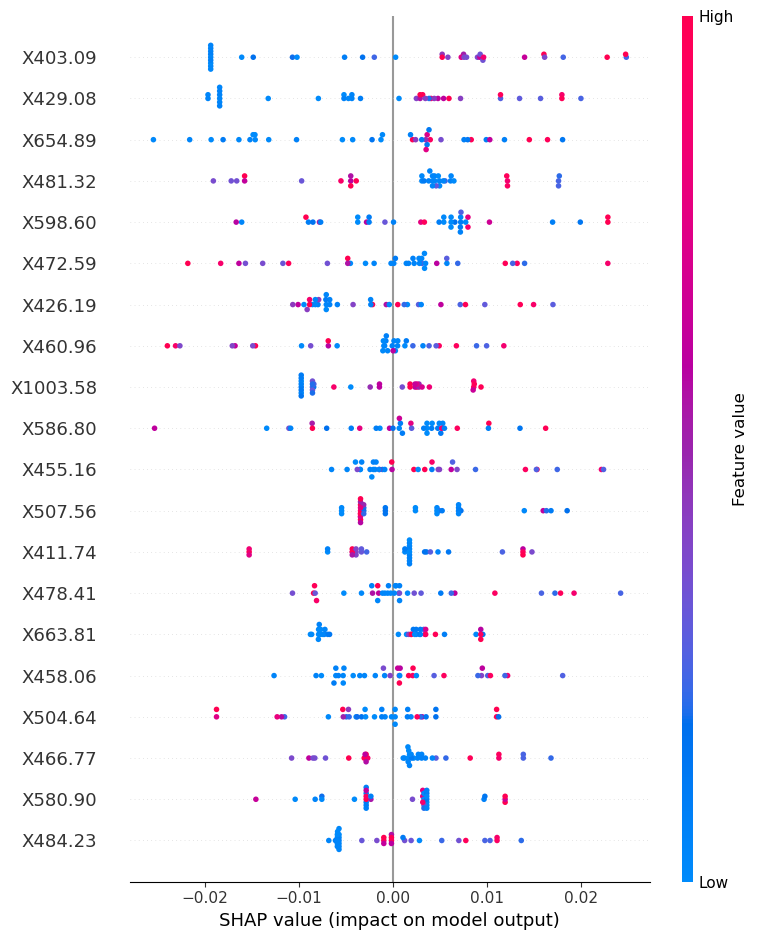

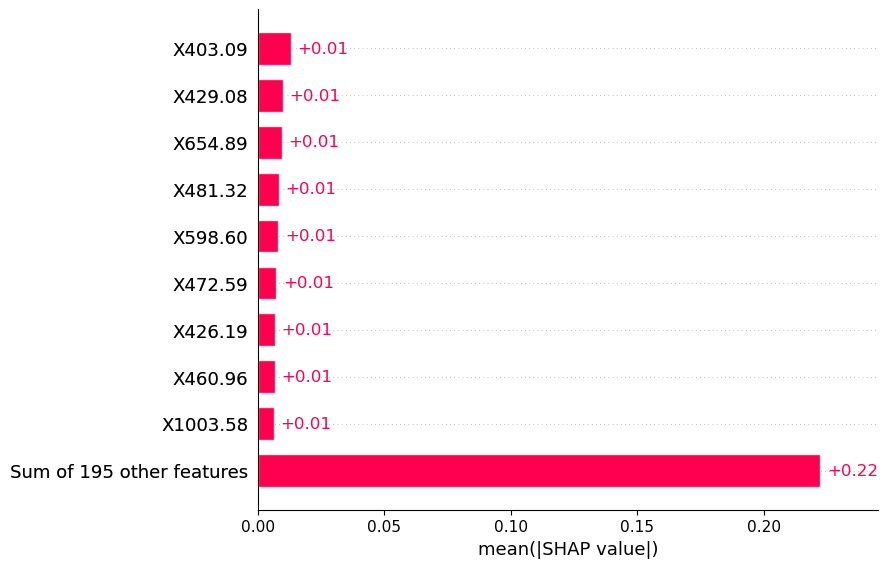

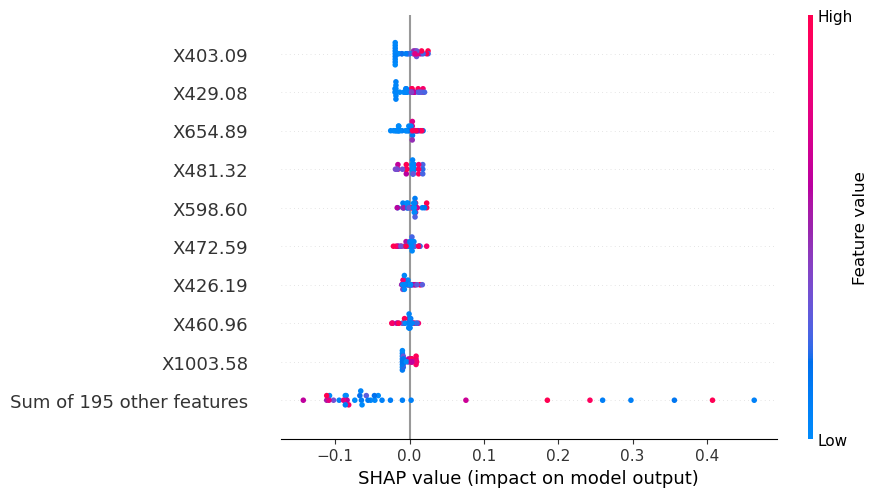

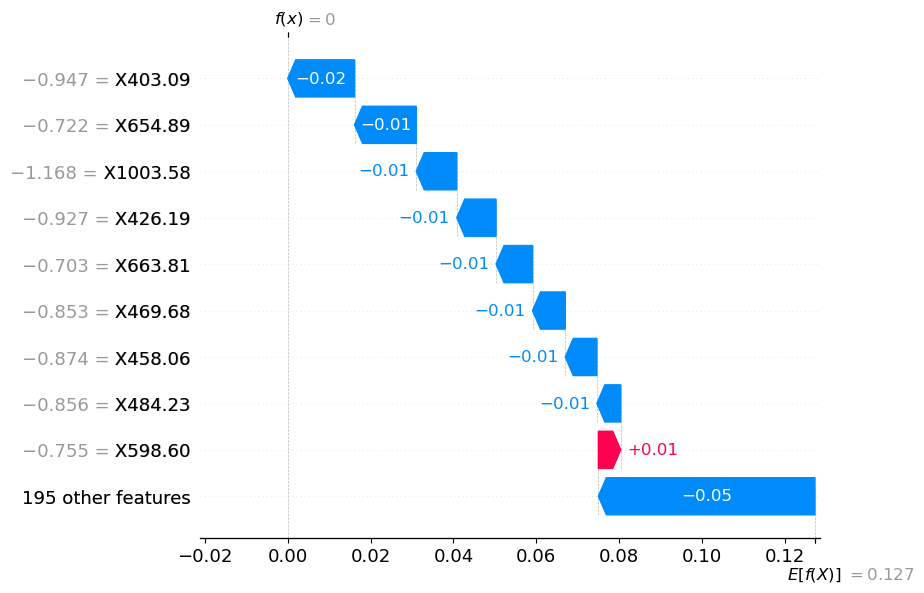

Generating SHAP plots for Class: +N-Fe_Sl


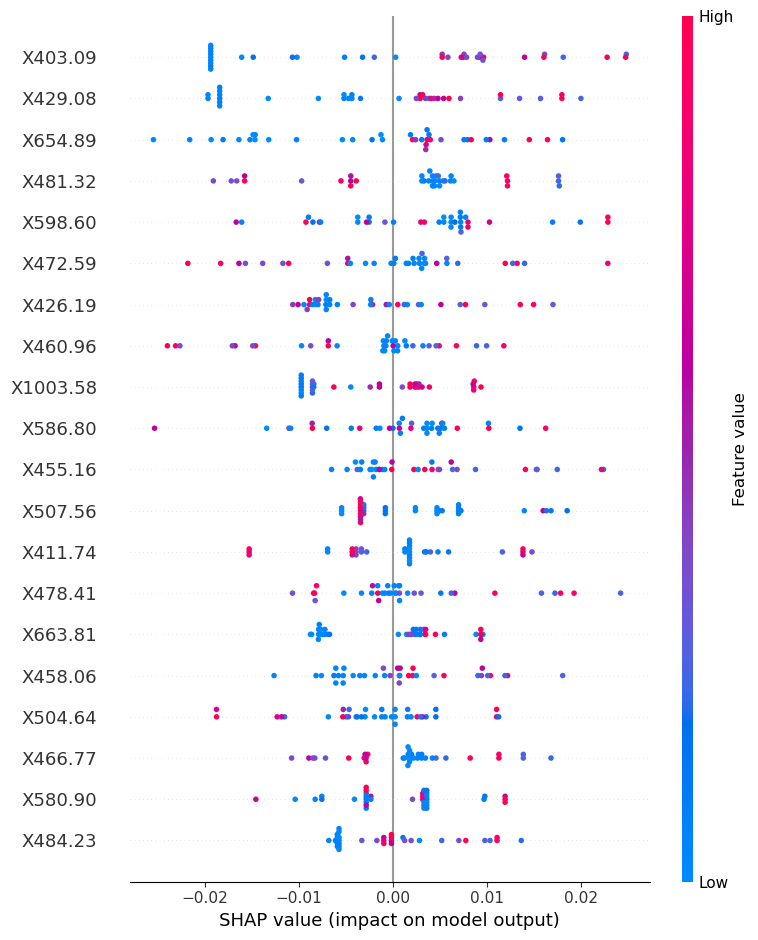

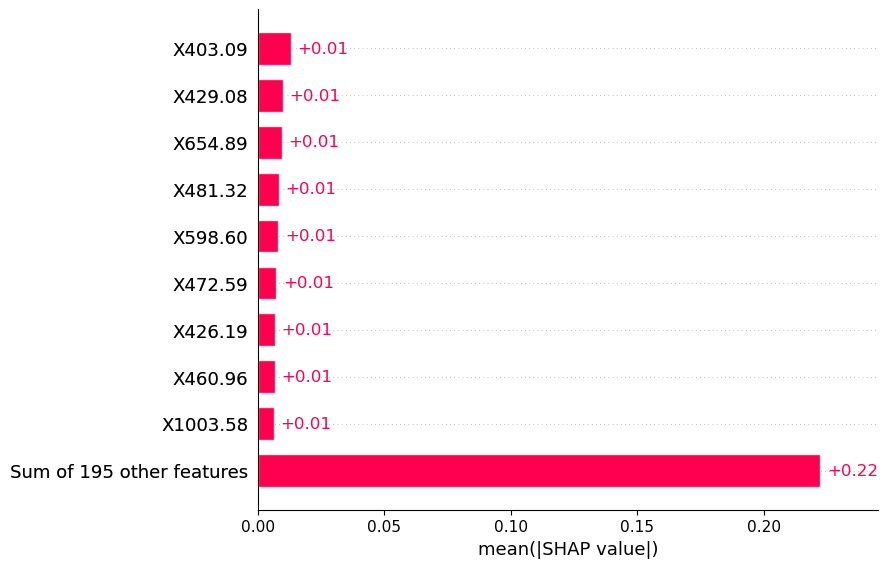

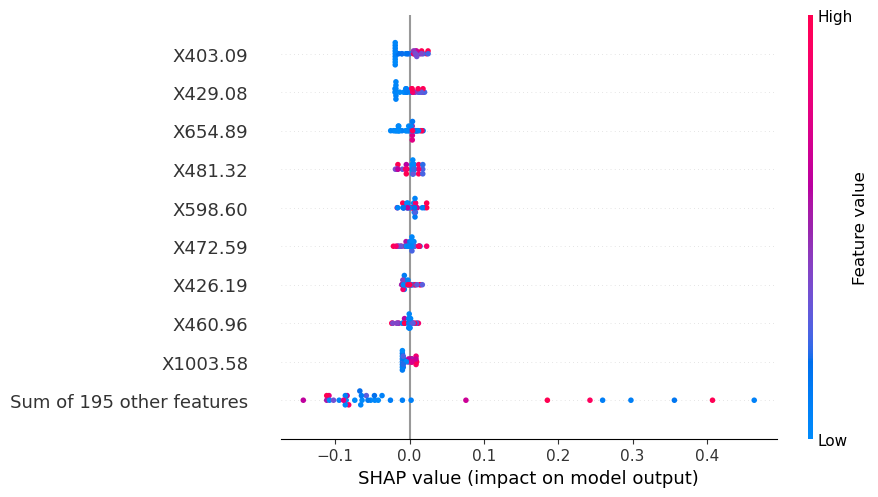

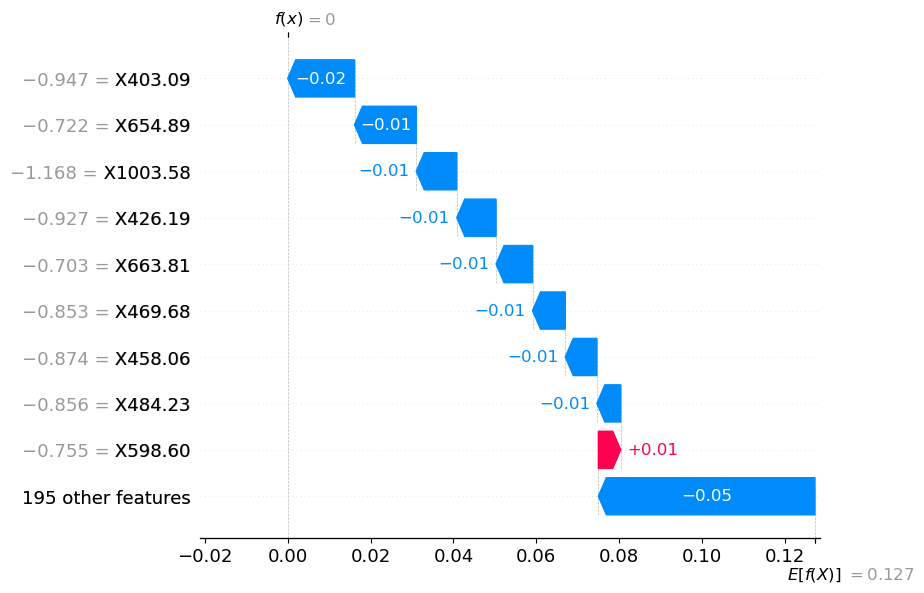

Generating SHAP plots for Class: +N-Fe_Zm


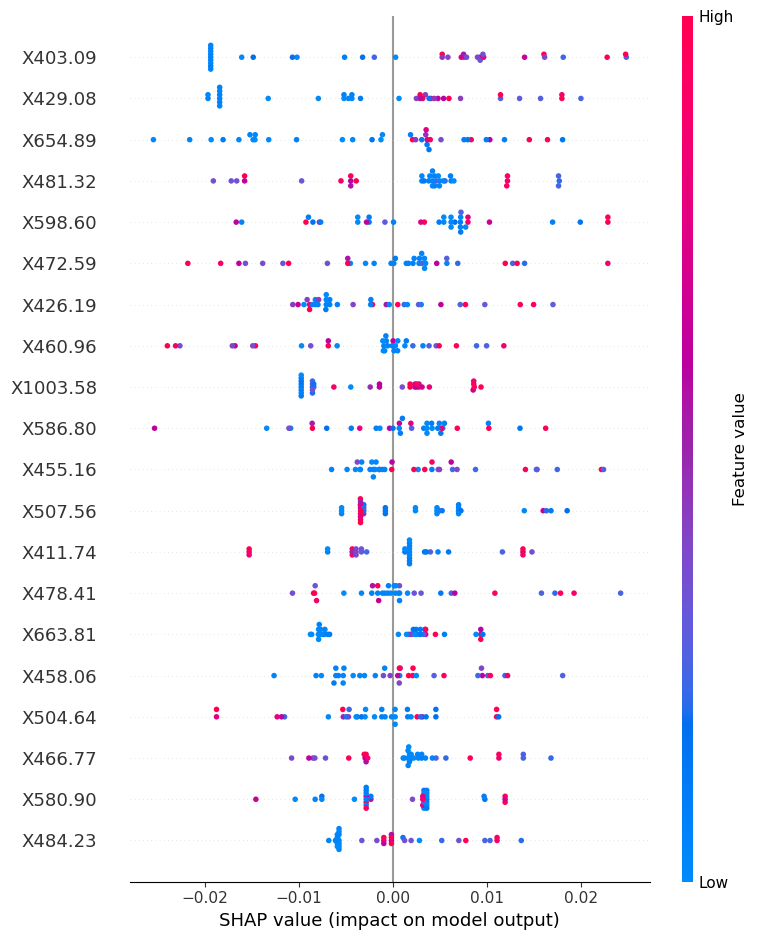

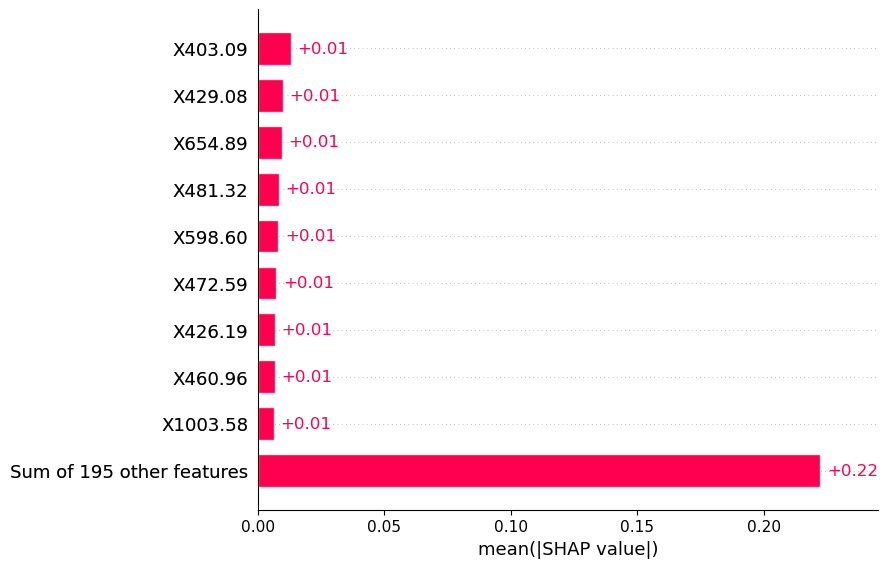

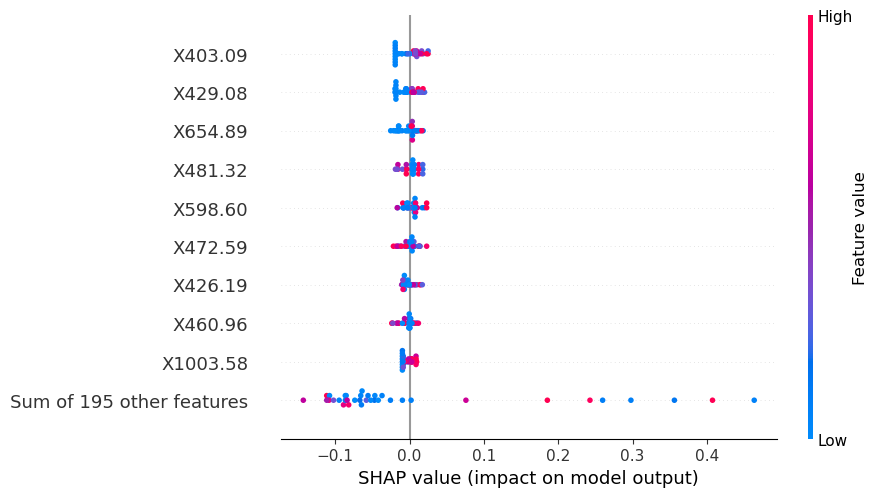

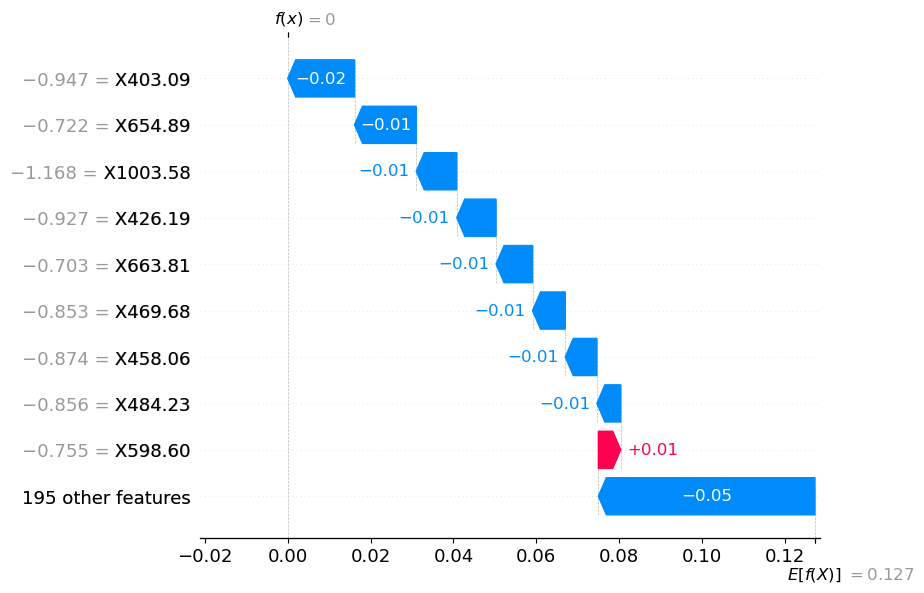

In [7]:
# Function to train and evaluate a model, and compute SHAP values
def train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names):
    # Define the parameter grid for Random Forest
    param_grid_rf = {
        'n_estimators': [10, 50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    random_state = 42

    # Perform GridSearchCV with cross-validation
    grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
    grid_search_rf.fit(X_train, y_train)
    best_params_rf = grid_search_rf.best_params_
    print("Best parameters for Random Forest:", best_params_rf)

    # Initialize the best Random Forest model
    best_rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)
    best_rf_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_rf = best_rf_model.predict(X_test)

    # Evaluate the model
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    print("\nRandom Forest - Test Set Accuracy:", accuracy_rf)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred_rf))

    # Confusion Matrix
    conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

    # Calculate SHAP values using TreeExplainer
    explainer_rf = shap.TreeExplainer(best_rf_model)
    shap_values_rf = explainer_rf.shap_values(X_test)
    print("shap_values_rf's shape", shap_values_rf.shape)
    return accuracy_rf, conf_matrix_rf, y_test, y_pred_rf, shap_values_rf, explainer_rf, feature_names

# Initialize random state
random_state = 42

# Grouping the data by plant using X_scaled and y
plant_groups_scaled = {
    "Plant1": (X_scaled[0:36], y[0:36]),
    "Plant2": (X_scaled[36:72], y[36:72]),
    "Plant3": (X_scaled[72:108], y[72:108]),
    "Plant4": (X_scaled[108:144], y[108:144])
}

# 😶😶😶😶😶😶😶😶😶😶😶😶
# Shuffle the data for each plant once before starting the for loops
for plant in plant_groups_scaled.keys():
    X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
    plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
accuracies_rf = []
conf_matrices_rf = []
all_y_true_rf = []
all_y_pred_rf = []
shap_values_list_rf = []
explainer_rf_list = []

# Number of splits
n_splits = 4

# Iterate to split the dataset
for i in range(n_splits):
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Iterate over each plant species
    for plant in plant_groups_scaled.keys():
        X = plant_groups_scaled[plant][0]
        y = plant_groups_scaled[plant][1]
        
        # Define the indices for the current split
        test_size = len(X) // n_splits
        test_indices = range(i * test_size, (i + 1) * test_size)
        train_indices = list(set(range(len(X))) - set(test_indices))
        
        # Split the data for the current iteration
        X_train_plant = X[train_indices]
        y_train_plant = y[train_indices]
        X_test_plant = X[test_indices]
        y_test_plant = y[test_indices]
        
        # Append to the respective lists
        X_train_list.append(X_train_plant)
        y_train_list.append(y_train_plant)
        X_test_list.append(X_test_plant)
        y_test_list.append(y_test_plant)

    # Concatenate the lists to form the final train and test sets
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    # 😶😶😶😶😶😶😶😶😶😶😶😶
    # Shuffle the concatenated train and test sets to remove any order-based bias
    X_train, y_train = shuffle(X_train, y_train, random_state=random_state)
    # X_test, y_test = shuffle(X_test, y_test, random_state=random_state)
    
    # Confirm the shape of the train and test sets
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    # Train and evaluate the model, and get SHAP values
    accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names)
    # accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names_reduced)

    
    accuracies_rf.append(accuracy_rf)
    conf_matrices_rf.append(conf_matrix_rf)
    all_y_true_rf.extend(y_true_rf)
    all_y_pred_rf.extend(y_pred_rf)
    shap_values_list_rf.append(shap_values_rf)
    explainer_rf_list.append(explainer_rf)

    # Plot the confusion matrix for each iteration
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - Iteration {i+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Calculate the average accuracy
average_accuracy_rf = np.mean(accuracies_rf)
print("\nAverage Accuracy Across 4 Iterations:", average_accuracy_rf)

# Combine confusion matrices by summing them up
# Combine confusion matrices by summing them up
combined_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)

# Plot the combined confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(combined_conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Combined Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate precision, recall, and F1-score using the aggregated results
precision_rf = precision_score(all_y_true_rf, all_y_pred_rf, average='micro')
recall_rf = recall_score(all_y_true_rf, all_y_pred_rf, average='micro')
f1_rf = f1_score(all_y_true_rf, all_y_pred_rf, average='micro')

print(f"\nOverall Precision: {precision_rf}")
print(f"Overall Recall: {recall_rf}")
print(f"Overall F1-score: {f1_rf}")

# Aggregate SHAP values
mean_shap_values_rf = np.mean([sv for sv in shap_values_list_rf], axis=0)
combined_base_values_rf = np.mean([explainer.expected_value for explainer in explainer_rf_list], axis=0)
print("combined_base_values_rf's shape", combined_base_values_rf)


# Create an Explanation object with combined SHAP values
combined_explanation_rf = shap.Explanation(
    values=mean_shap_values_rf[:, :, i],
    base_values=combined_base_values_rf,
    data=X_test,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Generate SHAP plots for each class
for i in range(shap_values_rf.shape[2]):
    print(f"Generating SHAP plots for Class: {le.classes_[i]}")

    # Summary Plot
    shap.summary_plot(combined_explanation_rf)
    
    # Bar Plot
    shap.plots.bar(combined_explanation_rf)
    
    # Beeswarm Plot
    shap.plots.beeswarm(combined_explanation_rf)
    
    # Waterfall Plot for the first instance
    shap.plots.waterfall(combined_explanation_rf[0])
